# Task 2: Corruption classification and hard-routed specialist autoencoders

Built directly on Task 1 (`genai-assignment1`): it imports Task 1's own `common/` code and reads Task 1's split, manifests and final configuration, so Tasks 1, 2 and 3 use identical corruptions, data split and test inputs. No Task 1 file is modified; Task 2 only adds `common/classifier.py`, `common/routing.py` and the `task2/` folder.

* **Part A, classifier:** a CNN that predicts clean, salt-and-pepper, blur or occlusion. Labels come from the runtime corruption pipeline and every training batch contains exactly the same number of each class. Cross-entropy loss; Optuna over learning rate, batch size, channel configuration, dropout and weight decay. Reports accuracy, macro precision, recall and F1, per-class metrics and a normalised confusion matrix.
* **Part B, specialists:** three denoising autoencoders with the Task 1 architecture and independent weights, each trained only on its own corruption. One shared Optuna search (learning rate, bottleneck size, channels, batch size, L1-to-SSIM weight) picks a common configuration; the three are then trained separately.
* **Part C, hard routing:** classifier, argmax, then the matching specialist; clean predictions take an identity bypass. Evaluated in oracle-routing and predicted-routing modes, with analysis of failures caused by classifier errors and a comparison against the Task 1 universal model.
* **Export:** classifier and specialists to ONNX, checked against PyTorch, plus a metadata file for the FastAPI backend. Checkpoints are saved in the format the Task 3 notebook loads.

## Using the Task 1 folder from another Google account

1. **On the Task 1 account:** in Google Drive, right-click `genai-assignment1` > Share, and add the Task 2 account's email as **Editor**. Viewer is not enough, because Task 2 writes into `genai-assignment1/task2/`.
2. **On the Task 2 account:** go to *Shared with me*, right-click `genai-assignment1` > **Organize > Add shortcut** > **My Drive**. Do not rename it. If you place it anywhere other than the top of My Drive, set `PROJECT_DIR_OVERRIDE` in the setup cell.
3. **W&B:** add the same `WANDB_API_KEY` as a Colab secret on this account (key icon in the left sidebar). The W&B account is separate from Google, so Task 2 runs appear in the same `genai-assignment1` W&B project as Task 1.

## How to run

1. **Runtime > Change runtime type > T4 GPU.**
2. Run all cells from top to bottom. Every Optuna study and training run resumes from Drive, so after a disconnect, reconnect and run all cells again.
3. Optional: set `QUICK_TEST = True` first for a short end-to-end check (outputs go to `task2_quicktest/`).

| Part | Approx. time on T4 |
|---|---|
| Setup and data | 2 min |
| A: classifier search (25 trials) and final training | 30 to 45 min |
| B: specialist search (15 trials, 3 models each) and final training | 70 to 110 min |
| C: routing evaluation, figures, ONNX export | 10 min |

## 0. Setup

In [1]:
!nvidia-smi -L || echo "No GPU detected: Runtime > Change runtime type > T4 GPU"
!pip -q install optuna wandb onnx onnxscript onnxruntime pytorch-msssim scikit-learn

GPU 0: Tesla T4 (UUID: GPU-368a778a-6420-c15b-3a09-ce7d4a7503d5)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.2

In [2]:
QUICK_TEST = False

SEED, IMG_SIZE, NUM_WORKERS = 42, 128, 2
CLF_TRIALS, CLF_TRIAL_EPOCHS, CLF_FINAL_EPOCHS, CLF_PATIENCE = 25, 8, 40, 8
SPEC_TRIALS, SPEC_TRIAL_EPOCHS, SPEC_FINAL_EPOCHS, SPEC_PATIENCE = 15, 8, 60, 12
WANDB_PROJECT = "genai-assignment1"
if QUICK_TEST:
    CLF_TRIALS, CLF_TRIAL_EPOCHS, CLF_FINAL_EPOCHS, CLF_PATIENCE = 2, 2, 2, 2
    SPEC_TRIALS, SPEC_TRIAL_EPOCHS, SPEC_FINAL_EPOCHS, SPEC_PATIENCE = 2, 1, 2, 2

In [3]:
import os, sys, glob, json
os.environ["WANDB_DIR"] = "/content/wandb_local"     # keep W&B's local cache off Drive (storage is tight)
os.makedirs(os.environ["WANDB_DIR"], exist_ok=True)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running on Colab')

# ------------------------------------------------------------------
# Locate genai-assignment1 (owned by the Task 1 account, shared to this one as a shortcut).
# ------------------------------------------------------------------
PROJECT_NAME = 'genai-assignment1'
PROJECT_DIR_OVERRIDE = ''      # only if the shortcut is not at the top of My Drive
candidates = ([PROJECT_DIR_OVERRIDE] if PROJECT_DIR_OVERRIDE else []) + \
             [f'/content/drive/MyDrive/{PROJECT_NAME}'] + \
             sorted(glob.glob(f'/content/drive/.shortcut-targets-by-id/*/{PROJECT_NAME}'))
PROJECT_DIR = next((p for p in candidates if os.path.isdir(f'{p}/task1') and os.path.isdir(f'{p}/common')), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        f"Could not find the shared {PROJECT_NAME} folder (with task1/ and common/ inside). Checked:\n  "
        + "\n  ".join(candidates)
        + f"\nShare {PROJECT_NAME} from the Task 1 account as Editor, then on this account use "
          "Shared with me > right-click > Organize > Add shortcut > My Drive, and re-run this cell.")

T1 = f'{PROJECT_DIR}/task1'
T2 = f'{PROJECT_DIR}/task2' + ('_quicktest' if QUICK_TEST else '')
T1_REQUIRED = {
    'shared code: corruptions':    f'{PROJECT_DIR}/common/corruptions.py',
    'shared code: data':           f'{PROJECT_DIR}/common/data.py',
    'shared code: models':         f'{PROJECT_DIR}/common/models.py',
    'shared code: losses_metrics': f'{PROJECT_DIR}/common/losses_metrics.py',
    'shared code: train_utils':    f'{PROJECT_DIR}/common/train_utils.py',
    'image cache (128 x 128)':     f'{PROJECT_DIR}/data/pets_128.npz',
    'split (seed 42)':             f'{PROJECT_DIR}/data/split_seed42.json',
    'validation manifest':         f'{PROJECT_DIR}/manifests/val_manifest.json',
    'test manifest':               f'{PROJECT_DIR}/manifests/test_manifest.json',
    'Task 1 final config':         f'{T1}/results/final_config.json',
}
T1_OPTIONAL = {'Task 1 per-sample test results': f'{T1}/results/test_per_sample.csv'}
print('Project folder:', PROJECT_DIR)
missing = []
for name, p in {**T1_REQUIRED, **T1_OPTIONAL}.items():
    ok = os.path.exists(p)
    print(f"  [{'found' if ok else 'MISSING'}] {name}: {p.replace(PROJECT_DIR, PROJECT_NAME)}")
    if not ok and name in T1_REQUIRED:
        missing.append(name)
if missing:
    raise FileNotFoundError(f'Required Task 1 files missing: {missing}')

probe = f'{PROJECT_DIR}/.task2_write_test'
try:
    open(probe, 'w').write('ok'); os.remove(probe)
except OSError as e:
    raise PermissionError(f'Cannot write to {PROJECT_DIR}: share it as Editor, not Viewer. ({e})')

PATHS = {k: f'{T2}/{k}' for k in ('checkpoints', 'onnx', 'optuna', 'figures', 'results')}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)
os.chdir(PROJECT_DIR)                 # %%writefile common/... below writes relative to this folder
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
print('Task 2 outputs ->', T2)

Mounted at /content/drive
Project folder: /content/drive/MyDrive/genai-assignment1
  [found] shared code: corruptions: genai-assignment1/common/corruptions.py
  [found] shared code: data: genai-assignment1/common/data.py
  [found] shared code: models: genai-assignment1/common/models.py
  [found] shared code: losses_metrics: genai-assignment1/common/losses_metrics.py
  [found] shared code: train_utils: genai-assignment1/common/train_utils.py
  [found] image cache (128 x 128): genai-assignment1/data/pets_128.npz
  [found] split (seed 42): genai-assignment1/data/split_seed42.json
  [found] validation manifest: genai-assignment1/manifests/val_manifest.json
  [found] test manifest: genai-assignment1/manifests/test_manifest.json
  [found] Task 1 final config: genai-assignment1/task1/results/final_config.json
  [found] Task 1 per-sample test results: genai-assignment1/task1/results/test_per_sample.csv
Task 2 outputs -> /content/drive/MyDrive/genai-assignment1/task2


## 1. Shared code

Task 1's `common/` modules are imported unchanged. The check below confirms they are the Task 1 versions (condition names, model class) before anything trains. Task 2 adds two new files: `common/classifier.py` (also used by Task 3 as the gate) and `common/routing.py`.

In [4]:
%%writefile common/classifier.py
"""Task 2 corruption classifier (also the gating network initialisation in Task 3).

Input: RGB tensor in [0, 1], shape (N, 3, 128, 128). Output: 4 logits in CONDITIONS order
(clean, salt_pepper, gaussian_blur, occlusion).
"""
import torch
import torch.nn as nn
import torch.nn.functional as F

CHANNEL_CONFIGS = {"small": (16, 32, 64, 128), "medium": (32, 64, 128, 256),
                   "wide": (48, 96, 192, 256), "deep_narrow": (32, 64, 96, 128)}


class CorruptionClassifier(nn.Module):
    """Four conv stages. The first stage runs at full resolution before any pooling, so fine
    detail (isolated noise pixels, the edge sharpness that blur removes) is still visible.
    Global average + max pooling, dropout, then a linear layer to 4 logits."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3, n_classes=4):
        super().__init__()
        layers, cin = [], 3
        for i, c in enumerate(channels):
            layers += [nn.Conv2d(cin, c, 3, 1, 1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True),
                       nn.Conv2d(c, c, 3, 1, 1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            if i < len(channels) - 1:
                layers.append(nn.MaxPool2d(2))
            cin = c
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(2 * cin, n_classes))

    def forward(self, x):
        f = self.features(x)
        f = torch.cat([F.adaptive_avg_pool2d(f, 1), F.adaptive_max_pool2d(f, 1)], 1).flatten(1)
        return self.head(f)

Writing common/classifier.py


In [5]:
%%writefile common/routing.py
"""Task 2: balanced classifier batches, classifier training and hard-routed restoration.

Builds on the Task 1 modules (corruptions, data, losses_metrics) so the corruptions, split
and manifests are exactly the ones Task 1 used.
"""
import math
import os
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Sampler

from .corruptions import CONDITIONS, apply_corruption, sample_params
from .data import to_tensor
from .losses_metrics import per_sample_metrics

EXPERT_NAMES = ["salt_pepper", "gaussian_blur", "occlusion"]
EXPERT_FOR_CLASS = {1: "salt_pepper", 2: "gaussian_blur", 3: "occlusion"}   # class 0 (clean) -> identity


class ForcedClassDataset(Dataset):
    """Index i encodes (image position, class) as i = pos * 4 + class. The sampler forces the
    condition; its severity is still sampled from the training ranges at load time."""

    def __init__(self, images_uint8):
        self.images = images_uint8

    def __len__(self):
        return len(self.images) * len(CONDITIONS)

    def __getitem__(self, i):
        pos, cls = divmod(int(i), len(CONDITIONS))
        clean = self.images[pos].astype(np.float32) / 255.0
        rng = np.random.default_rng(int(torch.randint(0, 2**31 - 1, (1,)).item()))
        params = sample_params(CONDITIONS[cls], rng, *clean.shape[:2])
        return to_tensor(apply_corruption(clean, params)), cls


class BalancedBatchSampler(Sampler):
    """Every batch holds exactly batch_size / 4 samples of each class. Each epoch every training
    image is used once, with its class assigned at random (25% of images per class)."""

    def __init__(self, n_images, batch_size, seed=42):
        assert batch_size % len(CONDITIONS) == 0, "batch size must be a multiple of 4"
        self.n, self.per_class = n_images, batch_size // len(CONDITIONS)
        self.rng = np.random.default_rng(seed)
        self.n_batches = (n_images // len(CONDITIONS)) // self.per_class

    def __len__(self):
        return self.n_batches

    def __iter__(self):
        perm = self.rng.permutation(self.n)
        groups = [perm[c::len(CONDITIONS)] for c in range(len(CONDITIONS))]
        for b in range(self.n_batches):
            sl = slice(b * self.per_class, (b + 1) * self.per_class)
            batch = [int(p) * len(CONDITIONS) + c for c, g in enumerate(groups) for p in g[sl]]
            self.rng.shuffle(batch)
            yield batch


class ClassifierWithProbs(nn.Module):
    """ONNX wrapper: returns logits and softmax probabilities."""

    def __init__(self, clf):
        super().__init__()
        self.clf = clf

    def forward(self, x):
        logits = self.clf(x)
        return logits, torch.softmax(logits, dim=1)


@torch.no_grad()
def predict(clf, loader, device):
    """For ManifestDataset loaders (x, clean, label, index). Returns probs, labels, indices."""
    clf.eval()
    probs, labels, idx = [], [], []
    for batch in loader:
        probs.append(torch.softmax(clf(batch[0].to(device)).float(), 1).cpu())
        labels.append(batch[2])
        idx.append(batch[3])
    return torch.cat(probs).numpy(), torch.cat(labels).numpy(), torch.cat(idx).numpy()


def classification_metrics(y_true, y_pred):
    from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
    labels = list(range(len(CONDITIONS)))
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    mp, mr, mf, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="macro",
                                                    zero_division=0)
    per_class = pd.DataFrame({"precision": p, "recall": r, "f1": f, "support": s}, index=CONDITIONS)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    return {"accuracy": float(accuracy_score(y_true, y_pred)), "macro_precision": float(mp),
            "macro_recall": float(mr), "macro_f1": float(mf)}, per_class, cm


def _scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def fit_classifier(clf, config, train_loader, val_loader, *, epochs, lr, weight_decay, device,
                   best_path=None, last_path=None, patience=None, trial=None, log_fn=None, verbose=True):
    """AdamW + cosine decay, cross-entropy. Model selection on validation macro-F1.
    best_path is saved as {"state_dict", "config", "epoch", "val"} (the format Task 3 loads).
    last_path stores the full training state, so a disconnected session resumes."""
    use_amp = torch.cuda.is_available()
    opt = torch.optim.AdamW(clf.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
    scaler = _scaler(use_amp)
    ce = nn.CrossEntropyLoss()
    history, best, start, bad, finished, extra = [], -math.inf, 0, 0, False, {}
    if last_path and os.path.exists(last_path):
        ck = torch.load(last_path, map_location=device, weights_only=False)
        clf.load_state_dict(ck["state_dict"]); opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"]); scaler.load_state_dict(ck["scaler"])
        history, best, bad, start, finished = ck["history"], ck["best"], ck["bad"], ck["epoch"] + 1, ck["finished"]
        extra = ck.get("extra", {})
        if verbose:
            print(f"Resumed from epoch {start} (best macro-F1 {best:.4f}, finished={finished})")
    if finished:
        return history, best
    if trial is not None:
        import optuna

    for ep in range(start, epochs):
        t0 = time.time()
        clf.train()
        tl, tc, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                logits = clf(x)
            loss = ce(logits.float(), y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tl += loss.item() * x.size(0)
            tc += (logits.argmax(1) == y).sum().item()
            n += x.size(0)
        probs, labels, _ = predict(clf, val_loader, device)
        val_loss = float(F.nll_loss(torch.log(torch.from_numpy(probs).clamp_min(1e-8)), torch.from_numpy(labels)))
        m, _, _ = classification_metrics(labels, probs.argmax(1))
        lr_now = opt.param_groups[0]["lr"]
        sched.step()
        row = {"epoch": ep, "train_loss": tl / n, "train_acc": tc / n, "val_loss": val_loss,
               "val_acc": m["accuracy"], "val_macro_f1": m["macro_f1"], "lr": lr_now,
               "epoch_time_s": time.time() - t0}
        history.append(row)
        if log_fn:
            log_fn(row)
        if verbose:
            print(f"ep {ep + 1:3d}/{epochs} | train loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} | "
                  f"val loss {val_loss:.4f} acc {m['accuracy']:.4f} F1 {m['macro_f1']:.4f} | {row['epoch_time_s']:.0f}s")
        if m["macro_f1"] > best:
            best, bad = m["macro_f1"], 0
            if best_path:
                torch.save({"state_dict": clf.state_dict(), "config": config, "epoch": ep, "val": m}, best_path)
        else:
            bad += 1
        if trial is not None:
            trial.report(m["macro_f1"], ep)
            if trial.should_prune():
                raise optuna.TrialPruned()
        stop = patience is not None and bad >= patience
        if last_path:
            torch.save({"state_dict": clf.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(),
                        "scaler": scaler.state_dict(), "history": history, "best": best, "bad": bad,
                        "epoch": ep, "finished": stop or ep == epochs - 1, "extra": extra}, last_path)
        if stop:
            if verbose:
                print(f"Early stopping: no improvement for {patience} epochs")
            break
    return history, best


class HardRouter:
    """Classifier -> argmax -> specialist. Clean predictions use an identity bypass: the input is
    returned unchanged and no expert is run."""

    def __init__(self, classifier, experts):
        self.clf = classifier.eval()
        self.experts = {k: v.eval() for k, v in experts.items()}

    @torch.no_grad()
    def route(self, x, route_labels):
        out = x.clone()
        for cls, name in EXPERT_FOR_CLASS.items():
            sel = route_labels == cls
            if sel.any():
                out[sel] = self.experts[name](x[sel]).float().clamp(0, 1)
        return out

    @torch.no_grad()
    def __call__(self, x):
        probs = torch.softmax(self.clf(x).float(), 1)
        pred = probs.argmax(1)
        return self.route(x, pred), probs, pred


@torch.no_grad()
def evaluate_routing(router, loader, device):
    """Oracle routing (true manifest label) and predicted routing (classifier argmax) for every
    entry. Outputs identical to the clean target get NaN PSNR (it would be infinite)."""
    rows = []
    for x, y, lab, idx in loader:
        x, y, lab = x.to(device), y.to(device), lab.to(device)
        pred_out, probs, pred = router(x)
        res = {"in": x, "oracle": router.route(x, lab), "pred": pred_out}
        m = {k: per_sample_metrics(o, y) for k, o in res.items()}
        for j in range(x.size(0)):
            r = {"index": int(idx[j]), "true": int(lab[j]), "pred": int(pred[j]), "confidence": float(probs[j].max())}
            for c, name in enumerate(CONDITIONS):
                r[f"p_{name}"] = float(probs[j, c])
            for k in res:
                for met in ("psnr", "ssim", "l1"):
                    r[f"{k}_{met}"] = float(m[k][met][j])
            rows.append(r)
    df = pd.DataFrame(rows)
    df["correct"] = df.true == df.pred
    for k in ("in", "oracle", "pred"):
        df.loc[df[f"{k}_l1"] == 0, f"{k}_psnr"] = np.nan
    df["routing_loss_psnr"] = df.oracle_psnr - df.pred_psnr
    df["routing_loss_ssim"] = df.oracle_ssim - df.pred_ssim
    return df

Writing common/routing.py


In [6]:
import importlib, hashlib, time, shutil, random, copy
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
import common.corruptions as cc, common.data as cd, common.models as cm, common.losses_metrics as cl
import common.train_utils as ct, common.classifier as ccls, common.routing as cr
for mod in (cc, cd, cm, cl, ct, ccls, cr):
    importlib.reload(mod)
from common.corruptions import CONDITIONS, COND2IDX, SEVERITIES, apply_corruption
from common.data import RuntimeCorruptionDataset, ManifestDataset
from common.models import ConvAutoencoder, count_params
from common.losses_metrics import per_sample_metrics
from common.train_utils import train_one_epoch, evaluate
from common.classifier import CorruptionClassifier, CHANNEL_CONFIGS
from common.routing import (ForcedClassDataset, BalancedBatchSampler, ClassifierWithProbs, predict,
                            classification_metrics, fit_classifier, HardRouter, evaluate_routing,
                            EXPERT_NAMES)
from torch.utils.data import DataLoader

assert CONDITIONS == ["clean", "salt_pepper", "gaussian_blur", "occlusion"], CONDITIONS
assert 'conditions' in RuntimeCorruptionDataset.__init__.__code__.co_varnames
print('Task 1 shared modules confirmed. Condition order:', CONDITIONS)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True
print('device:', device, '| torch', torch.__version__)

def loader(ds, batch_size, shuffle, workers=NUM_WORKERS, drop_last=None):
    # persistent_workers stays off: Part B runs three loaders at once and persistent pools exhaust RAM
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=workers,
                      pin_memory=device == 'cuda', drop_last=shuffle if drop_last is None else drop_last)

def savefig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(f"{PATHS['figures']}/{name}.{ext}", dpi=200, bbox_inches='tight')

def save_table(df, name):
    df.to_csv(f"{PATHS['results']}/{name}.csv")
    try:
        df.to_latex(f"{PATHS['results']}/{name}.tex", float_format='%.4f')
    except Exception as e:
        print('LaTeX export skipped:', e)

def describe(e):
    t = e['type']
    if t == 'clean':         return 'Clean'
    if t == 'salt_pepper':   return f"S&P p={e['p']:.2f} ({e['severity']})"
    if t == 'gaussian_blur': return f"Blur k={e['kernel']}, sigma={e['sigma']:.1f} ({e['severity']})"
    return f"Occlusion {e['n_rects']} rect, {100 * e['coverage']:.1f}% ({e['severity']})"

Task 1 shared modules confirmed. Condition order: ['clean', 'salt_pepper', 'gaussian_blur', 'occlusion']
device: cuda | torch 2.11.0+cu130


## 2. Data, split and manifests (read from Task 1)

Nothing is regenerated. The MD5 fingerprints of the split, manifests and shared code are saved as evidence that Task 2 used exactly Task 1's inputs.

In [7]:
d = np.load(T1_REQUIRED['image cache (128 x 128)'])
trainval_images, test_images, test_names = d['trainval_images'], d['test_images'], d['test_names']
split = json.load(open(T1_REQUIRED['split (seed 42)']))
train_images = trainval_images[np.array(split['train_idx'])]
val_images = trainval_images[np.array(split['val_idx'])]
val_entries = json.load(open(T1_REQUIRED['validation manifest']))['entries']
test_entries = json.load(open(T1_REQUIRED['test manifest']))['entries']
if QUICK_TEST:
    train_images, val_entries, test_entries = train_images[:256], val_entries[:128], test_entries[:300]
print(f"train {len(train_images)} | val entries {len(val_entries)} | test entries {len(test_entries)} "
      f"({len(test_images)} test images x 10 conditions)")

fingerprint = {k: hashlib.md5(open(p, 'rb').read()).hexdigest() for k, p in T1_REQUIRED.items()
               if not p.endswith('.npz')}
json.dump(fingerprint, open(f"{PATHS['results']}/task1_inputs_fingerprint.json", 'w'), indent=2)

val_meta = pd.DataFrame(val_entries).reset_index()        # 'index' = position in the manifest
test_meta = pd.DataFrame(test_entries).reset_index()
print('Validation conditions:', val_meta.type.value_counts().to_dict())

# Specialist settings inherited from Task 1 (chosen there by Optuna and the skip ablation)
t1_cfg = json.load(open(T1_REQUIRED['Task 1 final config']))
INHERIT = {'dropout': t1_cfg['dropout'], 'skip_channels': t1_cfg.get('skip_channels', 0)}
print('Task 1 final config:', t1_cfg)
print('Inherited by the specialists:', INHERIT)

train 2944 | val entries 736 | test entries 36690 (3669 test images x 10 conditions)
Validation conditions: {'occlusion': 184, 'clean': 184, 'salt_pepper': 184, 'gaussian_blur': 184}
Task 1 final config: {'lr': 0.00042057241220408675, 'batch_size': 16, 'base_channels': 48, 'latent_channels': 64, 'dropout': 0.2191038368562885, 'alpha': 0.5082890907740095, 'skip_channels': 0}
Inherited by the specialists: {'dropout': 0.2191038368562885, 'skip_channels': 0}


In [8]:
import wandb, optuna
from optuna.trial import TrialState
from optuna.visualization import matplotlib as ovm
optuna.logging.set_verbosity(optuna.logging.WARNING)
try:
    from google.colab import userdata
    wandb.login(key=userdata.get('WANDB_API_KEY'))
except Exception as e:
    print('Colab secret not found, falling back to interactive login:', e)
    wandb.login()
SUFFIX = '_quicktest' if QUICK_TEST else ''

def open_study(name, direction):
    name = name + SUFFIX
    local, remote = f'/content/{name}.db', f"{PATHS['optuna']}/{name}.db"
    if os.path.exists(remote) and not os.path.exists(local):
        shutil.copy(remote, local)
    study = optuna.create_study(study_name=name, storage=f'sqlite:///{local}', direction=direction,
                                sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=6),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
                                load_if_exists=True)
    def backup(study, trial):
        shutil.copy(local, remote)
        print(f"trial {trial.number:3d} {trial.state.name:9s} value={trial.value} params={trial.params}")
    return study, backup, remote

def run_study(study, objective, n_trials, backup):
    done = len([t for t in study.trials if t.state in (TrialState.COMPLETE, TrialState.PRUNED)])
    print(f'{done} trials already finished, running {max(n_trials - done, 0)} more')
    if n_trials - done > 0:
        study.optimize(objective, n_trials=n_trials - done, callbacks=[backup], gc_after_trial=True)

def report_study(study, prefix, search_space, objective_desc, epochs):
    comp = [t for t in study.trials if t.state == TrialState.COMPLETE]
    pr = [t for t in study.trials if t.state == TrialState.PRUNED]
    s = {'search_space': search_space, 'objective': objective_desc, 'epochs_per_trial': epochs,
         'sampler': 'TPE, seed 42, 6 start-up trials', 'pruner': 'MedianPruner(5 start-up trials, 2 warm-up epochs)',
         'n_trials_total': len(study.trials), 'n_complete': len(comp), 'n_pruned': len(pr),
         'best_trial': study.best_trial.number, 'best_value': study.best_value, 'best_params': study.best_params}
    json.dump(s, open(f"{PATHS['optuna']}/{prefix}_optuna_summary.json", 'w'), indent=2)
    df = study.trials_dataframe(); df.to_csv(f"{PATHS['optuna']}/{prefix}_optuna_trials.csv", index=False)
    print(json.dumps({k: v for k, v in s.items() if k != 'search_space'}, indent=2))
    for name, fn in [('history', ovm.plot_optimization_history), ('importance', ovm.plot_param_importances),
                     ('intermediate', ovm.plot_intermediate_values), ('parallel', ovm.plot_parallel_coordinate)]:
        try:
            fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()
        except Exception as e:
            print(f'{name} plot skipped: {e}')
    return s

RUN_IDS = f"{PATHS['results']}/wandb_run_ids.json"
def resumable_wandb(key, group, config):
    # Reuses the same W&B run after a disconnect, so curves continue instead of splitting
    ids = json.load(open(RUN_IDS)) if os.path.exists(RUN_IDS) else {}
    run = wandb.init(project=WANDB_PROJECT, group=group, name=key + SUFFIX, id=ids.get(key),
                     resume='allow', config=config)
    ids[key] = run.id; json.dump(ids, open(RUN_IDS, 'w'), indent=2)
    return run

Colab secret not found, falling back to interactive login: Secret WANDB_API_KEY does not exist.


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: emanhuda79 (emanhuda79-mm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Part A: corruption classifier

## A1. Balanced runtime batches

`ForcedClassDataset` encodes an index as `image_position * 4 + class`; `BalancedBatchSampler` builds every batch from exactly `batch_size / 4` samples per class. The condition is fixed by the sampler, but its severity is still sampled from the Task 1 training ranges when the image is loaded. The cell prints the class counts of the first batches as evidence.

batch 0: counts per class {'clean': 8, 'salt_pepper': 8, 'gaussian_blur': 8, 'occlusion': 8}
batch 1: counts per class {'clean': 8, 'salt_pepper': 8, 'gaussian_blur': 8, 'occlusion': 8}
batch 2: counts per class {'clean': 8, 'salt_pepper': 8, 'gaussian_blur': 8, 'occlusion': 8}
batch 3: counts per class {'clean': 8, 'salt_pepper': 8, 'gaussian_blur': 8, 'occlusion': 8}


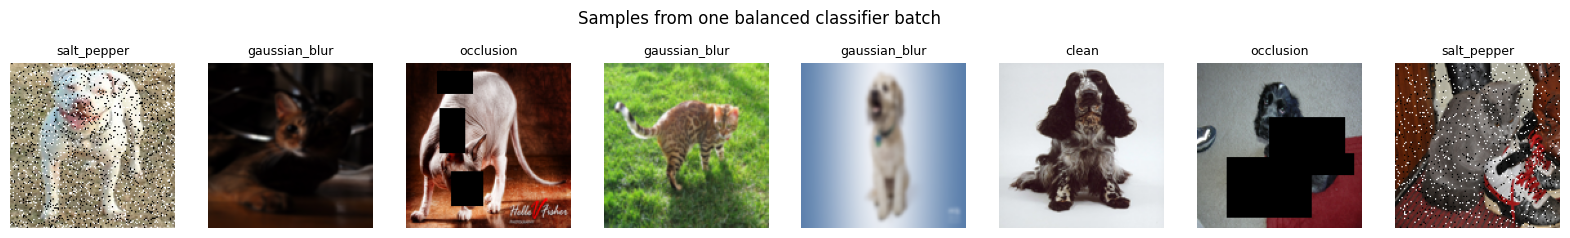

In [9]:
clf_train_ds = ForcedClassDataset(train_images)
def clf_loader(batch_size, seed=SEED):
    return DataLoader(clf_train_ds, batch_sampler=BalancedBatchSampler(len(train_images), batch_size, seed),
                      num_workers=NUM_WORKERS, pin_memory=device == 'cuda')
val_ds = ManifestDataset(val_images, val_entries)
test_ds = ManifestDataset(test_images, test_entries)
val_loader = loader(val_ds, 128, False)
test_loader = loader(test_ds, 128, False)

for b, (x, y) in enumerate(clf_loader(32)):
    print(f'batch {b}: counts per class', dict(zip(CONDITIONS, np.bincount(y.numpy(), minlength=4).tolist())))
    if b == 3: break
fig, axes = plt.subplots(1, 8, figsize=(20, 2.8))
for a, xi, yi in zip(axes, x[:8], y[:8]):
    a.imshow(xi.permute(1, 2, 0).numpy()); a.set_title(CONDITIONS[yi], fontsize=9); a.axis('off')
fig.suptitle('Samples from one balanced classifier batch'); savefig(fig, 'clf_balanced_batch'); plt.show()

## A2. Optuna search for the classifier

Search space: learning rate (log-uniform 1e-4 to 3e-3), batch size {32, 64, 128} (multiples of 4 for balancing), channel configuration {small, medium, wide, deep_narrow}, dropout (0 to 0.5), weight decay (log-uniform 1e-6 to 1e-2). Objective: validation macro-F1 (maximised), which weights all four classes equally.

0 trials already finished, running 25 more


epoch,▁▂▃▄▅▆▇█
epoch_time_s,█▁▁▁▁▁▁▁
lr,██▇▆▄▃▂▁
train_acc,▁▆▇▇████
train_loss,█▃▂▂▁▁▁▁
val_acc,▆▁▇█▇███
val_loss,▂█▁▁▁▁▁▁
val_macro_f1,▆▁▇█▇███
best_val_macro_f1,0.99592
epoch,7
epoch_time_s,4.0563


trial   0 COMPLETE  value=0.9959238829445515 params={'lr': 0.0003574712922600243, 'batch_size': 32, 'channels': 'deep_narrow', 'dropout': 0.3005575058716044, 'weight_decay': 0.0006796578090758161}


epoch,▁▂▃▄▅▆▇█
epoch_time_s,▁▁▄▄▂▁█▅
lr,██▇▆▄▃▂▁
train_acc,▁▇▇▇████
train_loss,█▃▂▁▁▁▁▁
val_acc,▁▄▇▇▇███
val_loss,█▄▃▁▂▁▁▁
val_macro_f1,▁▄▇▇▇███
best_val_macro_f1,0.99457
epoch,7
epoch_time_s,4.41045


trial   1 COMPLETE  value=0.9945650568601389 params={'lr': 0.00010725209743172001, 'batch_size': 32, 'channels': 'deep_narrow', 'dropout': 0.21597250932105788, 'weight_decay': 1.461896279370496e-05}


...

epoch,▁▂▃▄▅▆▇█
epoch_time_s,▄▇▁▁▃█▁▁
lr,██▇▆▄▃▂▁
train_acc,▁▇▇██▇██
train_loss,█▂▂▁▂▁▁▁
val_acc,▁███████
val_loss,█▁▁▁▁▁▁▁
val_macro_f1,▁███████
best_val_macro_f1,0.99864
epoch,7
epoch_time_s,3.48184


trial  23 COMPLETE  value=0.9986412943148505 params={'lr': 0.0010415640433692566, 'batch_size': 64, 'channels': 'deep_narrow', 'dropout': 0.05884377000430534, 'weight_decay': 0.0077277980383094694}


epoch,▁▅█
epoch_time_s,█▁▂
lr,█▆▁
train_acc,▁▇█
train_loss,█▂▁
val_acc,█▁▅
val_loss,█▇▁
val_macro_f1,█▁▅
epoch,2
epoch_time_s,3.74743
lr,0.00015


trial  24 PRUNED    value=0.9768647814227925 params={'lr': 0.0001779502645972552, 'batch_size': 32, 'channels': 'deep_narrow', 'dropout': 0.02312290585828218, 'weight_decay': 3.1855670816392146e-06}
{
  "objective": "validation macro-F1 (maximise)",
  "epochs_per_trial": 8,
  "sampler": "TPE, seed 42, 6 start-up trials",
  "pruner": "MedianPruner(5 start-up trials, 2 warm-up epochs)",
  "n_trials_total": 25,
  "n_complete": 11,
  "n_pruned": 14,
  "best_trial": 22,
  "best_value": 1.0,
  "best_params": {
    "lr": 0.00029424149348354894,
    "batch_size": 32,
    "channels": "small",
    "dropout": 0.11299312390843377,
    "weight_decay": 1.1698032759430235e-05
  }
}


/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()


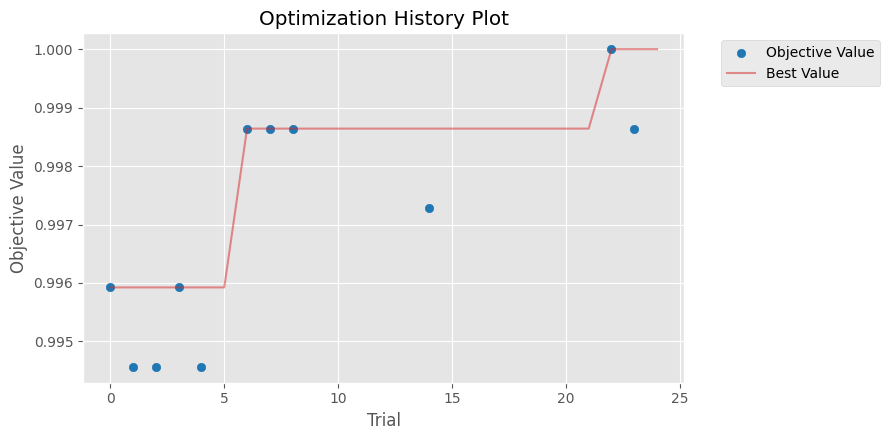

/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()


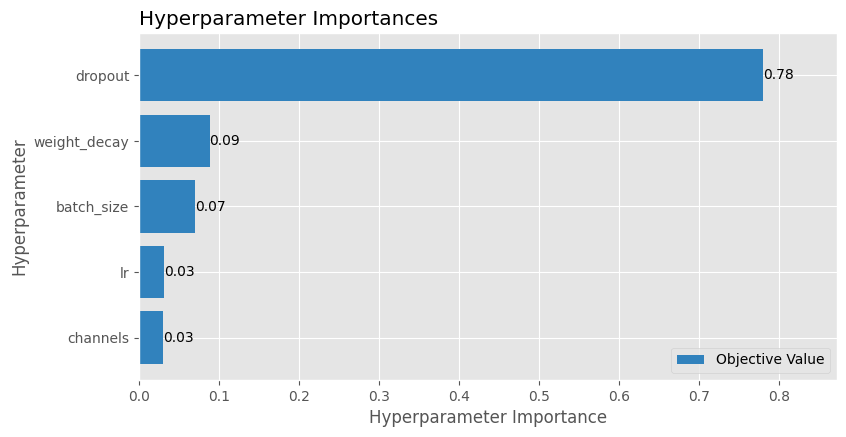

/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._intermediate_values.plot_intermediate_values is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


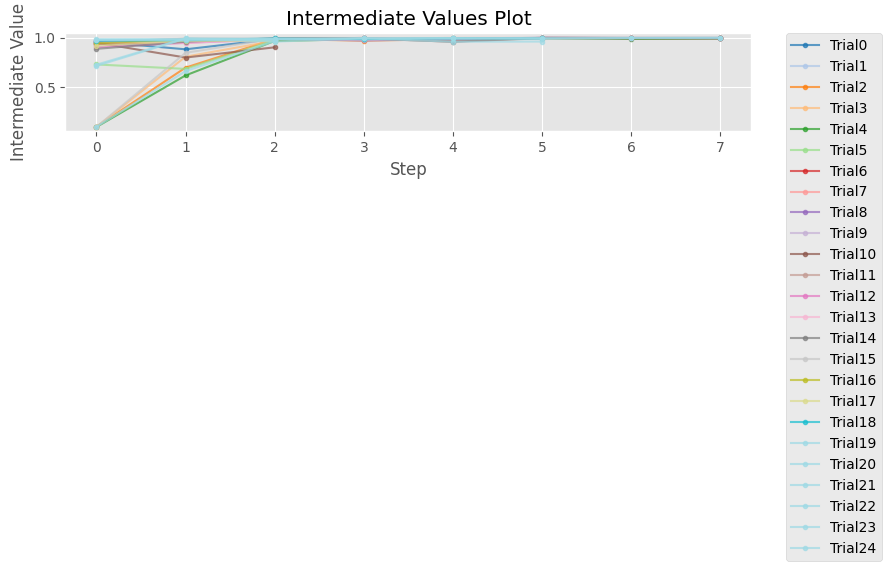

/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()


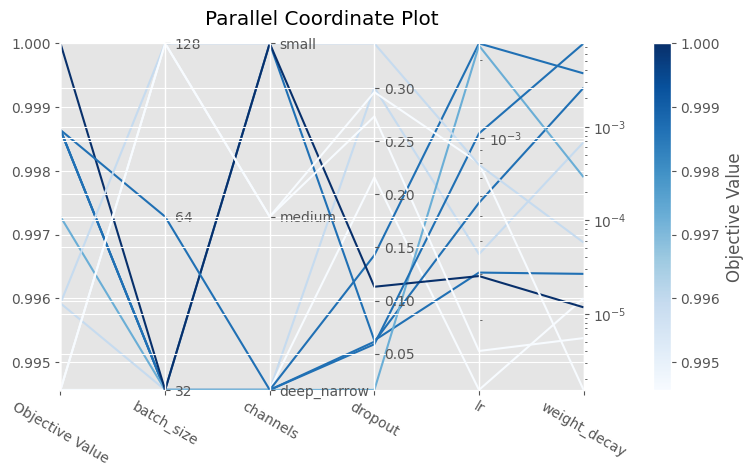

In [10]:
CLF_SPACE = {'lr': 'log-uniform [1e-4, 3e-3]', 'batch_size': [32, 64, 128],
             'channels': {k: list(v) for k, v in CHANNEL_CONFIGS.items()},
             'dropout': 'uniform [0.0, 0.5]', 'weight_decay': 'log-uniform [1e-6, 1e-2]'}
clf_study, clf_backup, CLF_DB = open_study('task2_classifier', 'maximize')

def clf_objective(trial):
    p = dict(lr=trial.suggest_float('lr', 1e-4, 3e-3, log=True),
             batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
             channels=trial.suggest_categorical('channels', list(CHANNEL_CONFIGS)),
             dropout=trial.suggest_float('dropout', 0.0, 0.5),
             weight_decay=trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True))
    seed_everything(SEED + trial.number)
    clf = CorruptionClassifier(CHANNEL_CONFIGS[p['channels']], p['dropout']).to(device)
    run = wandb.init(project=WANDB_PROJECT, group='task2-clf-optuna' + SUFFIX, name=f'clf-trial-{trial.number:03d}',
                     config={**p, 'trial': trial.number, 'params': count_params(clf)})
    try:
        _, best = fit_classifier(clf, None, clf_loader(p['batch_size'], trial.number), val_loader,
                                 epochs=CLF_TRIAL_EPOCHS, lr=p['lr'], weight_decay=p['weight_decay'], device=device,
                                 trial=trial, log_fn=wandb.log, verbose=False)
        run.summary.update({'state': 'complete', 'best_val_macro_f1': best})
        return best
    except optuna.TrialPruned:
        run.summary['state'] = 'pruned'; raise
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache(); run.summary['state'] = 'oom'; raise optuna.TrialPruned()
    finally:
        run.finish(); del clf; torch.cuda.empty_cache()

run_study(clf_study, clf_objective, CLF_TRIALS, clf_backup)
clf_optuna = report_study(clf_study, 'clf', CLF_SPACE, 'validation macro-F1 (maximise)', CLF_TRIAL_EPOCHS)

## A3. Final classifier training

{'lr': 0.00029424149348354894, 'batch_size': 32, 'channels': [16, 32, 64, 128], 'dropout': 0.11299312390843377, 'weight_decay': 1.1698032759430235e-05, 'channel_config': 'small', 'epochs': 40, 'patience': 8, 'optuna_trial': 22}


ep   1/40 | train loss 0.2681 acc 0.9117 | val loss 0.1468 acc 0.9443 F1 0.9442 | 3s
ep   2/40 | train loss 0.0763 acc 0.9766 | val loss 0.0753 acc 0.9742 F1 0.9741 | 3s
ep   3/40 | train loss 0.0632 acc 0.9810 | val loss 0.0455 acc 0.9864 F1 0.9864 | 5s
ep   4/40 | train loss 0.0505 acc 0.9840 | val loss 0.0594 acc 0.9810 F1 0.9810 | 4s
ep   5/40 | train loss 0.0403 acc 0.9874 | val loss 0.2281 acc 0.9103 F1 0.9087 | 3s
ep   6/40 | train loss 0.0330 acc 0.9908 | val loss 0.0313 acc 0.9878 F1 0.9878 | 3s
ep   7/40 | train loss 0.0267 acc 0.9898 | val loss 0.0263 acc 0.9932 F1 0.9932 | 4s
ep   8/40 | train loss 0.0341 acc 0.9878 | val loss 0.0308 acc 0.9918 F1 0.9918 | 4s
ep   9/40 | train loss 0.0270 acc 0.9905 | val loss 0.0835 acc 0.9688 F1 0.9688 | 3s
ep  10/40 | train loss 0.0321 acc 0.9898 | val loss 0.0222 acc 0.9932 F1 0.9932 | 3s
ep  11/40 | train loss 0.0194 acc 0.9946 | val loss 0.0234 acc 0.9932 F1 0.9932 | 3s
ep  12/40 | train loss 0.0166 acc 0.9929 | val loss 0.0469 acc 0.

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
epoch_time_s,▁▁▇▄▁▂▄▆▁▁▁▇▂▁▁▆▄▁▁▄▇▁▂▂█
lr,██████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▁▁
train_acc,▁▆▇▇▇▇▇▇▇▇███▇███████████
train_loss,█▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▄▆▇▇▁▇█▇▆██▇▇████████████
val_loss,▅▃▂▃█▂▂▂▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_macro_f1,▄▆▇▇▁▇█▇▆██▇▇████████████
epoch,24
epoch_time_s,5.00623
lr,0.0001


Best epoch 17: val accuracy 0.9986, macro-F1 0.9986


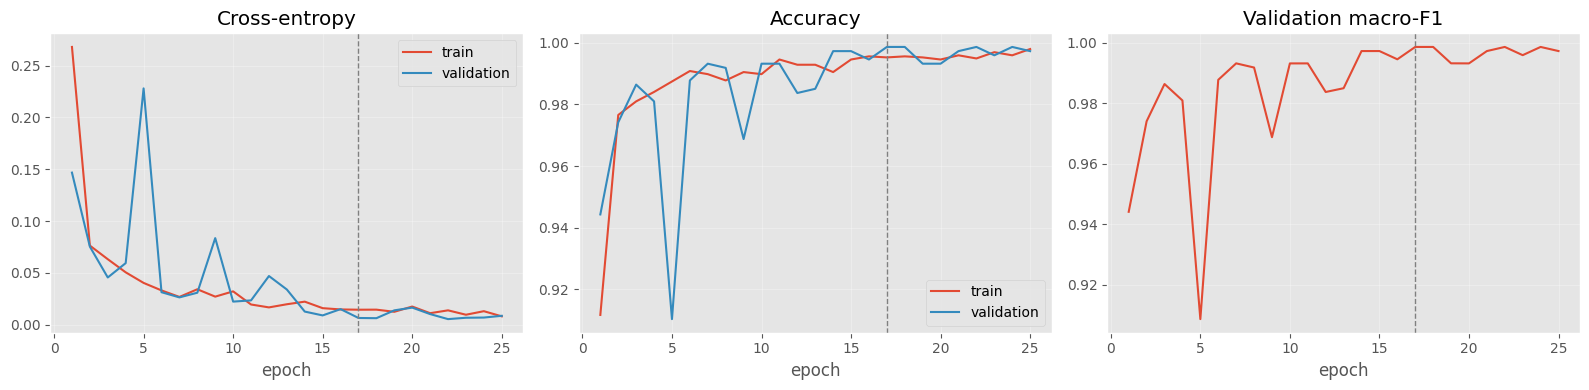

In [11]:
cbp = clf_study.best_params
CLF_CONFIG = {'channels': list(CHANNEL_CONFIGS[cbp['channels']]), 'dropout': cbp['dropout']}   # what Task 3 rebuilds from
CLF_FINAL = {**cbp, **CLF_CONFIG, 'channel_config': cbp['channels'], 'epochs': CLF_FINAL_EPOCHS,
             'patience': CLF_PATIENCE, 'optuna_trial': clf_study.best_trial.number}
json.dump(CLF_FINAL, open(f"{PATHS['results']}/clf_final_config.json", 'w'), indent=2); print(CLF_FINAL)

seed_everything(SEED)
clf = CorruptionClassifier(CLF_CONFIG['channels'], CLF_CONFIG['dropout']).to(device)
CLF_BEST, CLF_LAST = f"{PATHS['checkpoints']}/classifier_best.pt", f"{PATHS['checkpoints']}/classifier_last.pt"
run = resumable_wandb('task2-classifier-final', 'task2-final' + SUFFIX, {**CLF_FINAL, 'params': count_params(clf)})
clf_hist, _ = fit_classifier(clf, CLF_CONFIG, clf_loader(cbp['batch_size']), val_loader, epochs=CLF_FINAL_EPOCHS,
                             lr=cbp['lr'], weight_decay=cbp['weight_decay'], device=device,
                             best_path=CLF_BEST, last_path=CLF_LAST, patience=CLF_PATIENCE, log_fn=wandb.log)
run.finish()
clf_hist = pd.DataFrame(clf_hist); clf_hist.to_csv(f"{PATHS['results']}/clf_training_history.csv", index=False)
ck = torch.load(CLF_BEST, map_location=device, weights_only=False)
clf.load_state_dict(ck['state_dict']); clf.eval()
print(f"Best epoch {ck['epoch'] + 1}: val accuracy {ck['val']['accuracy']:.4f}, macro-F1 {ck['val']['macro_f1']:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4)); e = clf_hist.epoch + 1
ax[0].plot(e, clf_hist.train_loss, label='train'); ax[0].plot(e, clf_hist.val_loss, label='validation'); ax[0].set_title('Cross-entropy')
ax[1].plot(e, clf_hist.train_acc, label='train'); ax[1].plot(e, clf_hist.val_acc, label='validation'); ax[1].set_title('Accuracy')
ax[2].plot(e, clf_hist.val_macro_f1); ax[2].set_title('Validation macro-F1')
for a in ax: a.set_xlabel('epoch'); a.grid(alpha=.3); a.axvline(ck['epoch'] + 1, ls='--', c='grey', lw=1)
ax[0].legend(); ax[1].legend(); plt.tight_layout(); savefig(fig, 'clf_training_curves'); plt.show()

## A4. Classifier results (validation and test)


=== val === {'accuracy': 0.9986, 'macro_precision': 0.9986, 'macro_recall': 0.9986, 'macro_f1': 0.9986}


,precision,recall,f1,support
clean,0.9946,1.0000,0.9973,184
salt_pepper,1.0000,1.0000,1.0000,184
gaussian_blur,1.0000,0.9946,0.9973,184
occlusion,1.0000,1.0000,1.0000,184


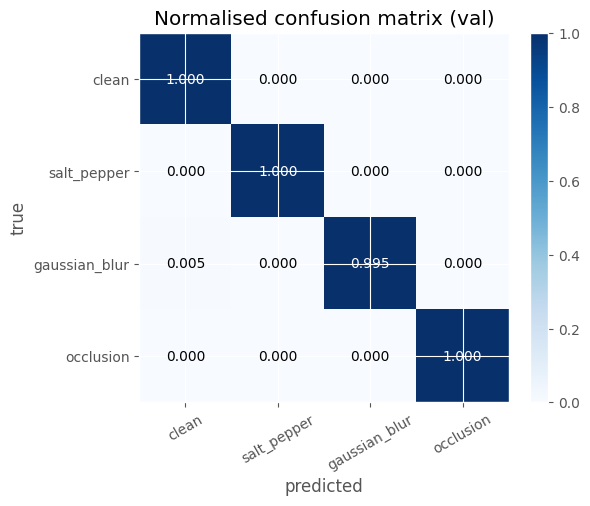


=== test === {'accuracy': 0.9986, 'macro_precision': 0.9984, 'macro_recall': 0.997, 'macro_f1': 0.9977}


,precision,recall,f1,support
clean,0.9973,0.9888,0.9930,3669
salt_pepper,1.0000,1.0000,1.0000,11007
gaussian_blur,0.9986,0.9995,0.9991,11007
occlusion,0.9976,0.9995,0.9985,11007


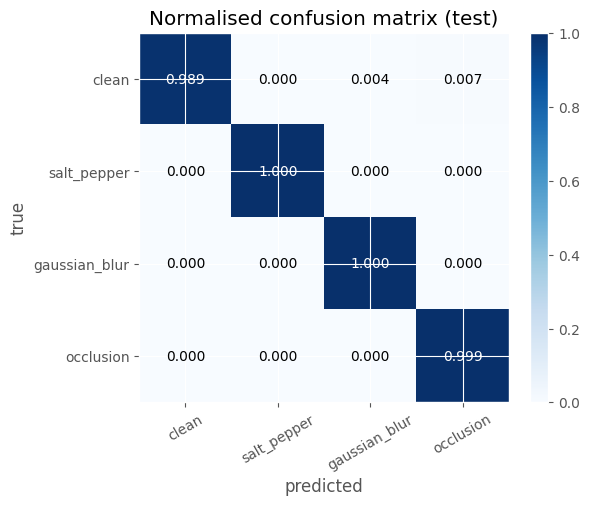

Test accuracy by corruption and severity:


severity,high,low,medium,none
type,,,,
clean,NaN,NaN,NaN,0.9888
gaussian_blur,1.0,0.9986,1.0,NaN
occlusion,1.0,0.9984,1.0,NaN
salt_pepper,1.0,1.0000,1.0,NaN


In [12]:
def plot_cm(cm_, title, name):
    fig, ax = plt.subplots(figsize=(5.4, 4.8))
    im = ax.imshow(cm_, cmap='Blues', vmin=0, vmax=1)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm_[i, j]:.3f}', ha='center', va='center', color='white' if cm_[i, j] > .5 else 'black')
    ax.set_xticks(range(4)); ax.set_yticks(range(4)); ax.set_xticklabels(CONDITIONS, rotation=30); ax.set_yticklabels(CONDITIONS)
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title(title); fig.colorbar(im, ax=ax, fraction=.046)
    savefig(fig, name); plt.show()

clf_results = {}
for split_name, ldr, meta_df in [('val', val_loader, val_meta), ('test', test_loader, test_meta)]:
    probs, labels, idx = predict(clf, ldr, device)
    overall, per_class, cmat = classification_metrics(labels, probs.argmax(1))
    clf_results[split_name] = overall
    print(f'\n=== {split_name} ===', {k: round(v, 4) for k, v in overall.items()}); display(per_class.round(4))
    save_table(per_class, f'clf_{split_name}_per_class')
    pd.DataFrame(cmat, index=CONDITIONS, columns=CONDITIONS).to_csv(f"{PATHS['results']}/clf_{split_name}_confusion_normalised.csv")
    plot_cm(cmat, f'Normalised confusion matrix ({split_name})', f'clf_confusion_{split_name}')
    if split_name == 'test':
        clf_test = pd.DataFrame({'index': idx, 'true': labels, 'pred': probs.argmax(1), 'conf': probs.max(1)}).merge(
            meta_df[['index', 'type', 'severity']], on='index')
json.dump(clf_results, open(f"{PATHS['results']}/clf_overall_metrics.json", 'w'), indent=2)
acc_ts = clf_test.assign(correct=clf_test.true == clf_test.pred).groupby(['type', 'severity']).correct.mean().unstack()
save_table(acc_ts, 'clf_test_accuracy_by_type_severity')
print('Test accuracy by corruption and severity:'); display(acc_ts.round(4))

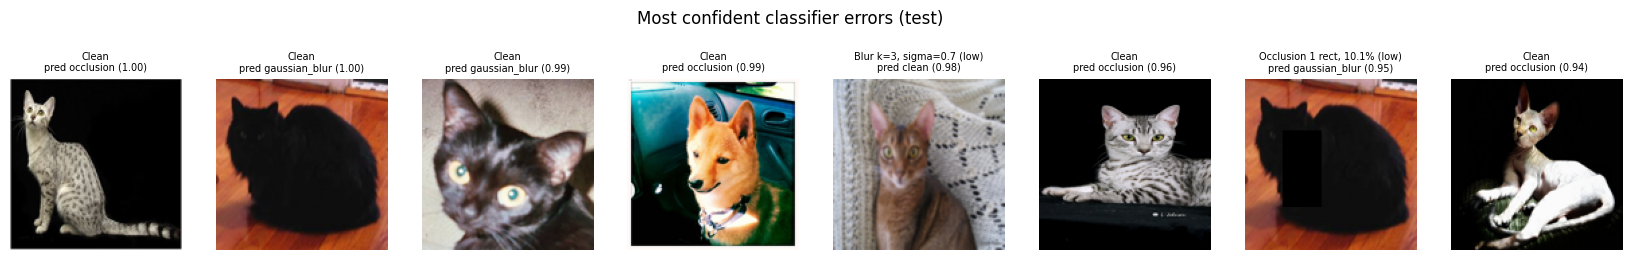

In [13]:
# Most confident classifier mistakes on the test set
wrong = clf_test[clf_test.true != clf_test.pred].sort_values('conf', ascending=False).head(8)
if len(wrong):
    fig, axes = plt.subplots(1, len(wrong), figsize=(2.6 * len(wrong), 3.2), squeeze=False)
    for a, (_, r) in zip(axes[0], wrong.iterrows()):
        e = test_entries[int(r['index'])]
        a.imshow(apply_corruption(test_images[e['img_idx']].astype(np.float32) / 255.0, e)); a.axis('off')
        a.set_title(f"{describe(e)}\npred {CONDITIONS[int(r.pred)]} ({r.conf:.2f})", fontsize=7)
    fig.suptitle('Most confident classifier errors (test)'); savefig(fig, 'clf_confident_errors'); plt.show()
else:
    print('No classifier errors on the test set.')

# Part B: specialist autoencoders

## B1. Shared Optuna search

Each trial trains **all three** specialists with the same hyperparameters, each only on its own corruption, and scores the trial by the mean of their validation objectives. The objective is the same as Task 1: `L1 + (1 - SSIM)`, lower is better, with fixed weights so it does not depend on the tuned alpha. Each specialist is validated only on validation-manifest images of its own corruption type. Search space: learning rate, batch size, bottleneck size (`latent_channels`), channel configuration (`base_channels`) and the L1 weight alpha, with the same ranges as Task 1. Dropout and skip channels are inherited from the Task 1 final model.

{'salt_pepper': 184, 'gaussian_blur': 184, 'occlusion': 184} validation images per specialist
15 trials already finished, running 0 more
{
  "objective": "mean validation L1 + (1 - SSIM) of the 3 specialists (minimise)",
  "epochs_per_trial": 8,
  "sampler": "TPE, seed 42, 6 start-up trials",
  "pruner": "MedianPruner(5 start-up trials, 2 warm-up epochs)",
  "n_trials_total": 15,
  "n_complete": 10,
  "n_pruned": 5,
  "best_trial": 14,
  "best_value": 0.455048864086469,
  "best_params": {
    "lr": 0.0003125838887063886,
    "batch_size": 16,
    "latent_channels": 16,
    "base_channels": 48,
    "alpha": 0.5264855710980522
  }
}


/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()


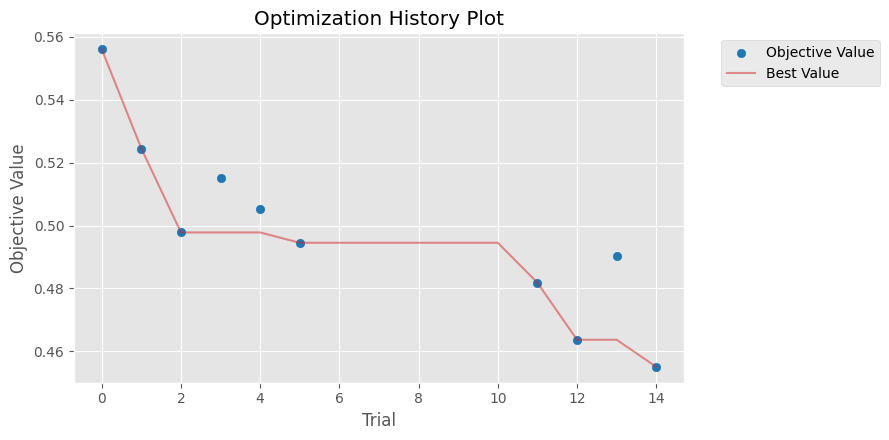

/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()


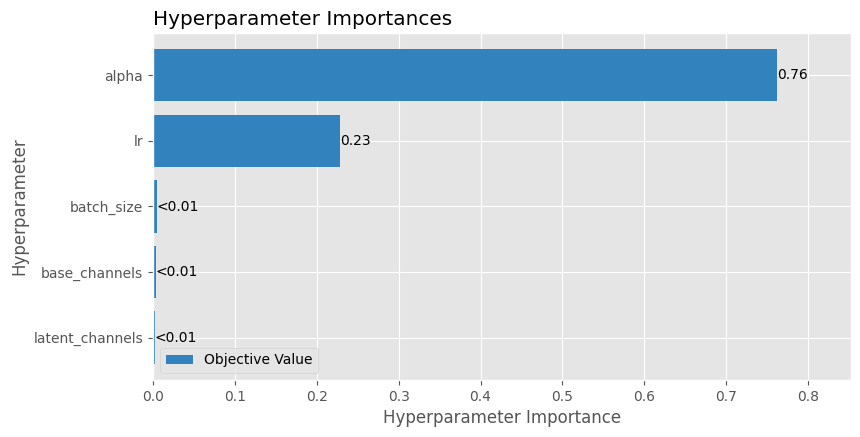

/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._intermediate_values.plot_intermediate_values is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()


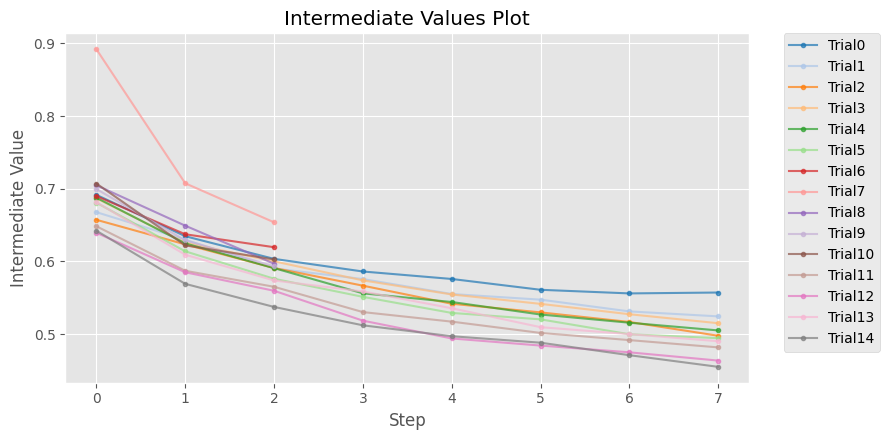

/tmp/ipykernel_1325/705236830.py:46: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fn(study); fig = plt.gcf(); fig.set_size_inches(9, 4.5); savefig(fig, f'{prefix}_optuna_{name}'); plt.show()


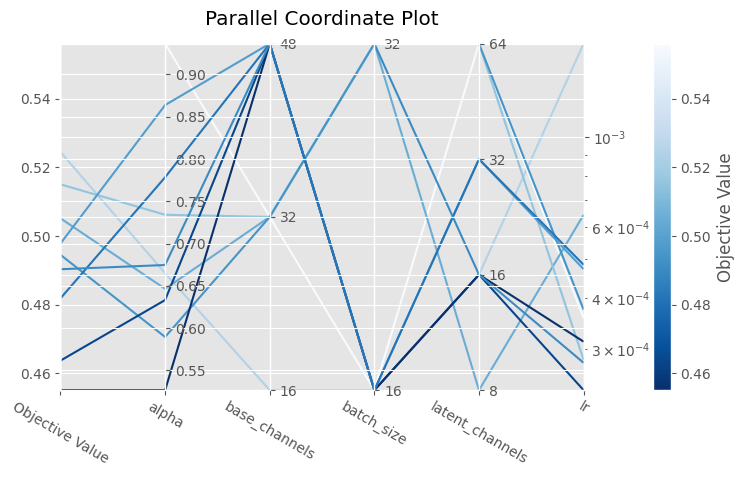

In [22]:
spec_train_ds = {t: RuntimeCorruptionDataset(train_images, conditions=[t]) for t in EXPERT_NAMES}
spec_val_entries = {t: [e for e in val_entries if e['type'] == t] for t in EXPERT_NAMES}
spec_val_loaders = {t: loader(ManifestDataset(val_images, spec_val_entries[t]), 64, False) for t in EXPERT_NAMES}
print({t: len(v) for t, v in spec_val_entries.items()}, 'validation images per specialist')

SPEC_SPACE = {'lr': 'log-uniform [1e-4, 3e-3]', 'batch_size': [16, 32, 64],
              'latent_channels (bottleneck = latent_channels x 8 x 8)': [8, 16, 32, 64],
              'base_channels (encoder c, 2c, 4c, 8c, 8c)': [16, 32, 48], 'alpha (L1 weight)': 'uniform [0.5, 0.95]',
              'inherited from Task 1': INHERIT}

def build_specialist(p):
    return ConvAutoencoder(p['base_channels'], p['latent_channels'], INHERIT['dropout'], INHERIT['skip_channels']).to(device)

spec_study, spec_backup, SPEC_DB = open_study('task2_specialists', 'minimize')

def spec_objective(trial):
    p = dict(lr=trial.suggest_float('lr', 1e-4, 3e-3, log=True),
             batch_size=trial.suggest_categorical('batch_size', [16, 32, 64]),
             latent_channels=trial.suggest_categorical('latent_channels', [8, 16, 32, 64]),
             base_channels=trial.suggest_categorical('base_channels', [16, 32, 48]),
             alpha=trial.suggest_float('alpha', 0.5, 0.95))
    seed_everything(SEED + trial.number)
    ms = {t: build_specialist(p) for t in EXPERT_NAMES}
    opts = {t: torch.optim.Adam(ms[t].parameters(), lr=p['lr']) for t in EXPERT_NAMES}
    tls = {t: loader(spec_train_ds[t], p['batch_size'], True) for t in EXPERT_NAMES}
    run = wandb.init(project=WANDB_PROJECT, group='task2-spec-optuna' + SUFFIX, name=f'spec-trial-{trial.number:03d}',
                     config={**p, **INHERIT, 'trial': trial.number})
    best = float('inf')
    try:
        for ep in range(SPEC_TRIAL_EPOCHS):
            objs, log = {}, {'epoch': ep}
            for t in EXPERT_NAMES:
                train_one_epoch(ms[t], tls[t], opts[t], p['alpha'], device)
                va, _ = evaluate(ms[t], spec_val_loaders[t], device)
                objs[t] = va['objective']
                log.update({f'{t}/val_objective': va['objective'], f'{t}/val_psnr': va['psnr'], f'{t}/val_ssim': va['ssim']})
            mean_obj = float(np.mean(list(objs.values())))
            log['mean_val_objective'] = mean_obj; wandb.log(log)
            best = min(best, mean_obj)
            trial.report(mean_obj, ep)
            if trial.should_prune():
                run.summary['state'] = 'pruned'; raise optuna.TrialPruned()
        run.summary.update({'state': 'complete', 'best_mean_val_objective': best})
        return best
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache(); run.summary['state'] = 'oom'; raise optuna.TrialPruned()
    finally:
        run.finish(); del ms, opts, tls; torch.cuda.empty_cache()

run_study(spec_study, spec_objective, SPEC_TRIALS, spec_backup)
spec_optuna = report_study(spec_study, 'spec', SPEC_SPACE,
                           'mean validation L1 + (1 - SSIM) of the 3 specialists (minimise)', SPEC_TRIAL_EPOCHS)

## B2. Independent training of the three specialists

Same architecture and hyperparameters, separate parameters, separate data (only their own corruption), separate checkpoints and W&B runs. Each `specialist_<name>_best.pt` is saved as `{"state_dict", "config"}`, which is what Task 3 loads.

{'lr': 0.0003125838887063886, 'batch_size': 16, 'latent_channels': 16, 'base_channels': 48, 'alpha': 0.5264855710980522, 'dropout': 0.2191038368562885, 'skip_channels': 0, 'epochs': 60, 'patience': 12, 'optuna_trial': 14}

========== specialist: salt_pepper ==========


salt_pepper ep   1 | train 0.3398 | val obj 0.6027 PSNR 18.18 SSIM 0.4888 | 32s
salt_pepper ep   2 | train 0.2841 | val obj 0.5379 PSNR 19.45 SSIM 0.5412 | 32s
salt_pepper ep   3 | train 0.2638 | val obj 0.5023 PSNR 19.54 SSIM 0.5763 | 31s
salt_pepper ep   4 | train 0.2505 | val obj 0.4765 PSNR 19.71 SSIM 0.5997 | 31s
salt_pepper ep   5 | train 0.2404 | val obj 0.4716 PSNR 20.02 SSIM 0.6034 | 31s
salt_pepper ep   6 | train 0.2314 | val obj 0.4354 PSNR 20.46 SSIM 0.6348 | 31s
salt_pepper ep   7 | train 0.2260 | val obj 0.4178 PSNR 20.85 SSIM 0.6504 | 31s
salt_pepper ep   8 | train 0.2200 | val obj 0.4159 PSNR 20.46 SSIM 0.6550 | 31s
salt_pepper ep   9 | train 0.2152 | val obj 0.4163 PSNR 20.63 SSIM 0.6531 | 31s
salt_pepper ep  10 | train 0.2119 | val obj 0.4024 PSNR 20.48 SSIM 0.6680 | 32s
salt_pepper ep  11 | train 0.2086 | val obj 0.3970 PSNR 21.19 SSIM 0.6685 | 32s
salt_pepper ep  12 | train 0.2060 | val obj 0.3833 PSNR 21.17 SSIM 0.6816 | 31s
salt_pepper ep  13 | train 0.2030 | val 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇████
epoch_time_s,▇█▁▅▂▃▃▆▅▄▃▃▃▆▆▄▃▃▅▆▄▃▄▅▆▃▃▃▃▅▅▄▃▃▅▆▃▂▂▃
lr,███████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁
train_l1,█▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_ssim,▁▃▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████
val_l1,█▅▅▄▃▂▂▂▃▃▂▂▂▂▂▂▂▂▁▂▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_objective,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_psnr,▁▃▃▅▆▅▅▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇███████████████
val_ssim,▁▂▃▄▄▆▆▆▆▆▇▇▇▇▇▇▇█▇█████████████████████
best_epoch,59



========== specialist: gaussian_blur ==========


gaussian_blur ep   1 | train 0.3411 | val obj 0.5876 PSNR 18.74 SSIM 0.4984 | 31s
gaussian_blur ep   2 | train 0.2830 | val obj 0.5257 PSNR 19.43 SSIM 0.5539 | 31s
gaussian_blur ep   3 | train 0.2626 | val obj 0.5029 PSNR 19.54 SSIM 0.5763 | 31s
gaussian_blur ep   4 | train 0.2485 | val obj 0.4695 PSNR 20.01 SSIM 0.6049 | 31s
gaussian_blur ep   5 | train 0.2379 | val obj 0.4473 PSNR 20.52 SSIM 0.6241 | 31s
gaussian_blur ep   6 | train 0.2301 | val obj 0.4374 PSNR 20.06 SSIM 0.6377 | 31s
gaussian_blur ep   7 | train 0.2244 | val obj 0.4287 PSNR 20.89 SSIM 0.6401 | 31s
gaussian_blur ep   8 | train 0.2204 | val obj 0.4148 PSNR 20.59 SSIM 0.6562 | 31s
gaussian_blur ep   9 | train 0.2154 | val obj 0.3998 PSNR 20.71 SSIM 0.6704 | 31s
gaussian_blur ep  10 | train 0.2117 | val obj 0.3909 PSNR 21.25 SSIM 0.6750 | 31s
gaussian_blur ep  11 | train 0.2089 | val obj 0.3807 PSNR 21.19 SSIM 0.6856 | 31s
gaussian_blur ep  12 | train 0.2062 | val obj 0.3911 PSNR 21.02 SSIM 0.6767 | 31s
gaussian_blur ep

epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇███
epoch_time_s,▆▆▁▄▇▃▃▄▇▇▄▃▄▄▇▅▅▄▄▄▆▄▄▃▃█▅▅▃▅▇▆▄█▄▃▃▆▇▄
lr,████████▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train_l1,█▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_ssim,▁▂▃▄▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
val_l1,█▆▅▄▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_objective,█▆▆▅▄▄▃▃▂▂▂▂▂▂▁▁▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_psnr,▁▂▃▄▄▆▅▆▆▇▆▇▇▇▇▇▆▇█▇▇▆██▇▇▇█████████████
val_ssim,▁▃▄▅▅▆▆▇▇▇▇▇▇▇█▇████▇███████████████████
best_epoch,56



========== specialist: occlusion ==========


occlusion ep   1 | train 0.3665 | val obj 0.6940 PSNR 17.09 SSIM 0.4129 | 33s
occlusion ep   2 | train 0.3204 | val obj 0.6429 PSNR 17.36 SSIM 0.4573 | 32s
occlusion ep   3 | train 0.3024 | val obj 0.6120 PSNR 17.74 SSIM 0.4841 | 31s
occlusion ep   4 | train 0.2900 | val obj 0.5779 PSNR 18.22 SSIM 0.5121 | 31s
occlusion ep   5 | train 0.2813 | val obj 0.5994 PSNR 17.34 SSIM 0.5032 | 32s
occlusion ep   6 | train 0.2732 | val obj 0.5511 PSNR 18.55 SSIM 0.5371 | 31s
occlusion ep   7 | train 0.2672 | val obj 0.5400 PSNR 18.36 SSIM 0.5478 | 31s
occlusion ep   8 | train 0.2611 | val obj 0.5306 PSNR 18.44 SSIM 0.5562 | 31s
occlusion ep   9 | train 0.2574 | val obj 0.5218 PSNR 18.62 SSIM 0.5638 | 31s
occlusion ep  10 | train 0.2558 | val obj 0.5149 PSNR 18.64 SSIM 0.5707 | 31s
occlusion ep  11 | train 0.2531 | val obj 0.5155 PSNR 18.28 SSIM 0.5720 | 31s
occlusion ep  12 | train 0.2515 | val obj 0.5015 PSNR 18.73 SSIM 0.5829 | 31s
occlusion ep  13 | train 0.2476 | val obj 0.4972 PSNR 18.96 SSIM

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch_time_s,█▃▂▃▁▁▂▂▂▂▂▂▂▁▂▂▂▃▂▂▁▁▂▃▂▁▁▁▂▂▁▁▂▂▂▁▁▂▂▁
lr,███████▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_l1,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_ssim,▁▂▃▃▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
val_l1,█▆▄▇▄▃▄▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
val_objective,█▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_psnr,▁▂▃▂▅▅▅▄▆▆▆▆▆▆▇▆▇▇▇▇▇██▇▇██▇▇███████████
val_ssim,▁▃▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇████▇████████████████
best_epoch,59


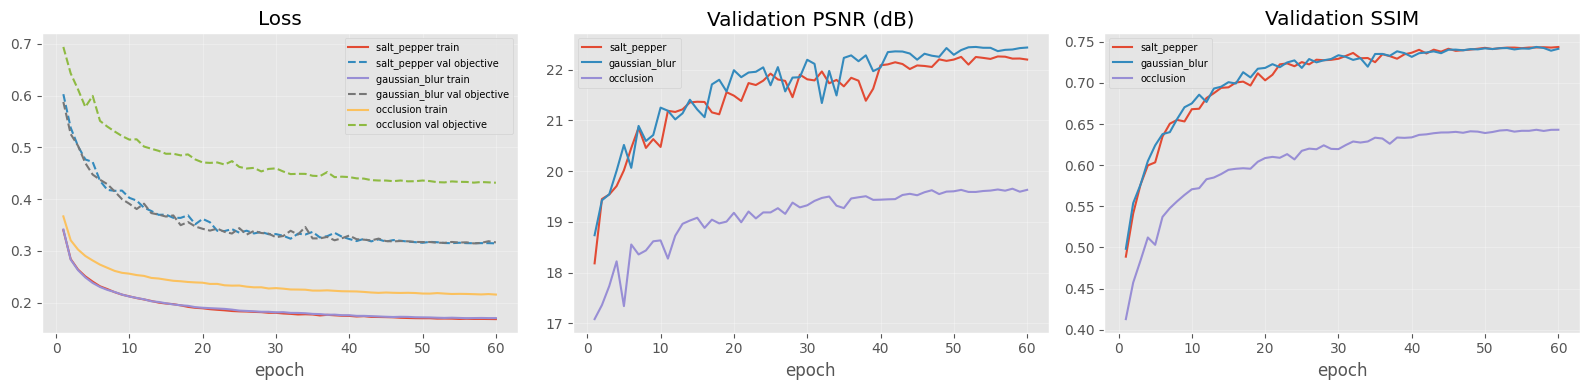

,val_in_psnr,val_out_psnr,val_in_ssim,val_out_ssim,params
specialist,,,,,
salt_pepper,16.1315,22.1975,0.3588,0.7436,9271603
gaussian_blur,28.6269,22.3887,0.8436,0.7436,9271603
occlusion,13.1707,19.6310,0.6969,0.6430,9271603


In [15]:
sbp = spec_study.best_params
SPEC_CONFIG = {'base_channels': sbp['base_channels'], 'latent_channels': sbp['latent_channels'], **INHERIT}
SPEC_FINAL = {**sbp, **INHERIT, 'epochs': SPEC_FINAL_EPOCHS, 'patience': SPEC_PATIENCE,
              'optuna_trial': spec_study.best_trial.number}
json.dump(SPEC_FINAL, open(f"{PATHS['results']}/spec_final_config.json", 'w'), indent=2); print(SPEC_FINAL)

def fit_specialist(name, i):
    seed_everything(SEED + 100 * (i + 1))
    m = build_specialist(sbp)
    opt = torch.optim.Adam(m.parameters(), lr=sbp['lr'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SPEC_FINAL_EPOCHS, eta_min=sbp['lr'] * 0.01)
    best_p, last_p = f"{PATHS['checkpoints']}/specialist_{name}_best.pt", f"{PATHS['checkpoints']}/specialist_{name}_last.pt"
    hist, best, best_ep, start, finished = [], float('inf'), -1, 0, False
    if os.path.exists(last_p):
        ckl = torch.load(last_p, map_location=device, weights_only=False)
        m.load_state_dict(ckl['state_dict']); opt.load_state_dict(ckl['opt']); sched.load_state_dict(ckl['sched'])
        hist, best, best_ep, start, finished = ckl['history'], ckl['best'], ckl['best_epoch'], ckl['epoch'] + 1, ckl['finished']
        print(f'Resumed {name} from epoch {start} (finished={finished})')
    if not finished:
        run = resumable_wandb(f'task2-specialist-{name}-final', 'task2-final' + SUFFIX,
                              {**SPEC_FINAL, 'specialist': name, 'params': count_params(m), 'latent_dim': m.latent_dim()})
        tl = loader(spec_train_ds[name], sbp['batch_size'], True)
        for ep in range(start, SPEC_FINAL_EPOCHS):
            t0 = time.time()
            tr = train_one_epoch(m, tl, opt, sbp['alpha'], device)
            va, _ = evaluate(m, spec_val_loaders[name], device)
            lr_now = opt.param_groups[0]['lr']; sched.step()
            row = {'epoch': ep, 'lr': lr_now, 'epoch_time_s': time.time() - t0,
                   **{f'train_{k}': v for k, v in tr.items()},
                   **{f'val_{k}': va[k] for k in ('l1', 'psnr', 'ssim', 'objective')}}
            hist.append(row); wandb.log(row)
            print(f"{name} ep {ep + 1:3d} | train {tr['loss']:.4f} | val obj {va['objective']:.4f} "
                  f"PSNR {va['psnr']:.2f} SSIM {va['ssim']:.4f} | {row['epoch_time_s']:.0f}s")
            if va['objective'] < best:
                best, best_ep = va['objective'], ep
                torch.save({'state_dict': m.state_dict(), 'config': SPEC_CONFIG, 'epoch': ep, 'val': va}, best_p)
            stop = ep - best_ep >= SPEC_PATIENCE
            torch.save({'state_dict': m.state_dict(), 'opt': opt.state_dict(), 'sched': sched.state_dict(), 'history': hist,
                        'best': best, 'best_epoch': best_ep, 'epoch': ep,
                        'finished': stop or ep == SPEC_FINAL_EPOCHS - 1}, last_p)
            if stop:
                print(f'{name}: early stopping (best epoch {best_ep + 1})'); break
        run.summary.update({'best_val_objective': best, 'best_epoch': best_ep}); run.finish()
    m.load_state_dict(torch.load(best_p, map_location=device, weights_only=False)['state_dict']); m.eval()
    return m, pd.DataFrame(hist)

experts, spec_hist = {}, {}
for i, t in enumerate(EXPERT_NAMES):
    print(f'\n========== specialist: {t} ==========')
    experts[t], spec_hist[t] = fit_specialist(t, i)
    spec_hist[t].to_csv(f"{PATHS['results']}/spec_{t}_training_history.csv", index=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for t, h in spec_hist.items():
    ax[0].plot(h.epoch + 1, h.train_loss, label=f'{t} train'); ax[0].plot(h.epoch + 1, h.val_objective, '--', label=f'{t} val objective')
    ax[1].plot(h.epoch + 1, h.val_psnr, label=t); ax[2].plot(h.epoch + 1, h.val_ssim, label=t)
for a, ttl in zip(ax, ['Loss', 'Validation PSNR (dB)', 'Validation SSIM']):
    a.set_title(ttl); a.set_xlabel('epoch'); a.grid(alpha=.3); a.legend(fontsize=7)
plt.tight_layout(); savefig(fig, 'spec_training_curves'); plt.show()

rows = []
for t in EXPERT_NAMES:
    va, ps = evaluate(experts[t], spec_val_loaders[t], device, return_per_sample=True)
    rows.append({'specialist': t, 'val_in_psnr': float(ps['in_psnr'].mean()), 'val_out_psnr': va['psnr'],
                 'val_in_ssim': float(ps['in_ssim'].mean()), 'val_out_ssim': va['ssim'], 'params': count_params(experts[t])})
spec_val = pd.DataFrame(rows).set_index('specialist'); save_table(spec_val, 'spec_val_results'); display(spec_val.round(4))

# Part C: hard-routed restoration

## C1. Oracle vs predicted routing on the test set

Every test-manifest entry is restored twice: with the **true** label choosing the expert (oracle) and with the **classifier** choosing it (predicted). Clean routing returns the input unchanged. When the output equals the clean target its PSNR would be infinite, so it is stored as blank and the table reports `pred_identity_rate`; SSIM is 1 in that case.

In [16]:
router = HardRouter(clf, experts)
t0 = time.time()
rt = evaluate_routing(router, test_loader, device)
rt = rt.merge(test_meta[[c for c in ['index', 'img_idx', 'type', 'severity', 'p', 'kernel', 'sigma', 'n_rects', 'coverage']
                         if c in test_meta]], on='index')
rt.to_csv(f"{PATHS['results']}/routing_test_per_sample.csv", index=False)
print(f'{len(rt)} test entries in {time.time() - t0:.0f}s')

def routing_table(df, by):
    g = df.groupby(by)
    return pd.DataFrame({
        'n': g.size(), 'routing_acc': g.correct.mean(),
        'in_psnr': g.in_psnr.mean(), 'oracle_psnr': g.oracle_psnr.mean(), 'pred_psnr': g.pred_psnr.mean(),
        'in_ssim': g.in_ssim.mean(), 'oracle_ssim': g.oracle_ssim.mean(), 'pred_ssim': g.pred_ssim.mean(),
        'pred_identity_rate': g.pred.apply(lambda s: (s == 0).mean()),
        'ssim_lost_to_routing': g.routing_loss_ssim.mean()})

rt_type = routing_table(rt, 'type').reindex(CONDITIONS)
rt_type.loc['all corrupted'] = routing_table(rt[rt.type != 'clean'].assign(all=1), 'all').iloc[0]
rt_sev = routing_table(rt[rt.type != 'clean'], ['type', 'severity'])
rt_sev = rt_sev.reindex(pd.MultiIndex.from_product([CONDITIONS[1:], SEVERITIES], names=['type', 'severity']))
save_table(rt_type, 'routing_test_by_type'); save_table(rt_sev, 'routing_test_by_type_severity')
print('Oracle vs predicted routing, by condition'); display(rt_type.round(4))
print('By corruption and severity'); display(rt_sev.round(4))

36690 test entries in 312s
Oracle vs predicted routing, by condition


,n,routing_acc,in_psnr,oracle_psnr,pred_psnr,in_ssim,oracle_ssim,pred_ssim,pred_identity_rate,ssim_lost_to_routing
type,,,,,,,,,,
clean,3669.0,0.9888,NaN,NaN,21.8852,1.0000,1.0000,0.9972,0.9888,0.0028
salt_pepper,11007.0,1.0000,16.3841,21.8480,21.8480,0.3821,0.7362,0.7362,0.0000,0.0000
gaussian_blur,11007.0,0.9995,27.8209,21.8092,21.8131,0.8136,0.7271,0.7272,0.0005,-0.0001
occlusion,11007.0,0.9995,13.6414,19.7696,19.7731,0.7127,0.6555,0.6555,0.0005,-0.0000
all corrupted,33021.0,0.9997,19.2821,21.1423,21.1447,0.6361,0.7062,0.7063,0.0003,-0.0001


By corruption and severity


n  routing_acc  in_psnr  oracle_psnr  pred_psnr  \
type          severity                                                       
salt_pepper   low       3669       1.0000  20.1336      21.8426    21.8426   
              medium    3669       1.0000  15.8752      21.8525    21.8525   
              high      3669       1.0000  13.1437      21.8488    21.8488   
gaussian_blur low       3669       0.9986  32.3359      21.7351    21.7467   
              medium    3669       1.0000  26.7735      21.8844    21.8844   
              high      3669       1.0000  24.3532      21.8082    21.8082   
occlusion     low       3669       0.9984  16.7345      20.7535    20.7639   
              medium    3669       1.0000  13.3570      19.8596    19.8596   
              high      3669       1.0000  10.8327      18.6959    18.6959   

                        in_ssim  oracle_ssim  pred_ssim  pred_identity_rate  \
type          severity                                                        
salt_pepper   low        0.6025       0.7373     0.7373              0.0000   
              medium     0.3396       0.7366     0.7366              0.0000   
              high       0.2041       0.7346     0.7346              0.0000   
gaussian_blur low        0.9436       0.7342     0.7345              0.0014   
              medium     0.8057       0.7335     0.7335              0.0000   
              high       0.6916       0.7137     0.7137              0.0000   
occlusion     low        0.8618       0.6961     0.6963              0.0014   
              medium     0.7305       0.6620     0.6620              0.0000   
              high       0.5457       0.6083     0.6083              0.0000   

                        ssim_lost_to_routing  
type          severity                        
salt_pepper   low                     0.0000  
              medium                  0.0000  
              high                    0.0000  
gaussian_blur low                    -0.0004  
              medium                 -0.0000  
              high                   -0.0000  
occlusion     low                    -0.0001  
              medium                  0.0000  
              high                    0.0000

In [17]:
# Task 1 universal model vs Task 2 hard routing on exactly the same test entries
t1_path = T1_OPTIONAL['Task 1 per-sample test results']
if os.path.exists(t1_path):
    t1r = pd.read_csv(t1_path)[['index', 'psnr', 'ssim']].rename(columns={'psnr': 'universal_psnr', 'ssim': 'universal_ssim'})
    cmp = rt.merge(t1r, on='index')
    cmp_tbl = cmp.groupby(['type', 'severity'])[['universal_psnr', 'oracle_psnr', 'pred_psnr',
                                                 'universal_ssim', 'oracle_ssim', 'pred_ssim']].mean()
    save_table(cmp_tbl, 'task1_vs_task2_test'); print('Task 1 universal vs Task 2 hard routing'); display(cmp_tbl.round(4))
else:
    print('Task 1 test_per_sample.csv not found, so the comparison table is skipped.')

Task 1 universal vs Task 2 hard routing


universal_psnr  oracle_psnr  pred_psnr  \
type          severity                                           
clean         none             21.7541          NaN    21.8852   
gaussian_blur high             21.6267      21.8082    21.8082   
              low              21.8630      21.7351    21.7467   
              medium           21.9114      21.8844    21.8844   
occlusion     high             18.5078      18.6959    18.6959   
              low              20.6694      20.7535    20.7639   
              medium           19.7246      19.8596    19.8596   
salt_pepper   high             21.7744      21.8488    21.8488   
              low              21.7936      21.8426    21.8426   
              medium           21.8118      21.8525    21.8525   

                        universal_ssim  oracle_ssim  pred_ssim  
type          severity                                          
clean         none              0.7353       1.0000     0.9972  
gaussian_blur high              0.6897       0.7137     0.7137  
              low               0.7349       0.7342     0.7345  
              medium            0.7254       0.7335     0.7335  
occlusion     high              0.6022       0.6083     0.6083  
              low               0.6984       0.6961     0.6963  
              medium            0.6607       0.6620     0.6620  
salt_pepper   high              0.7274       0.7346     0.7346  
              low               0.7345       0.7373     0.7373  
              medium            0.7323       0.7366     0.7366

## C2. Failures caused by classifier errors

Routing errors are grouped by (true corruption, predicted class). `ssim_lost` is how much SSIM predicted routing lost compared with oracle routing on the same image. A large loss means the classifier error caused the restoration failure; a near-zero loss means the error was harmless (for example a very mild blur sent to the identity branch).

52 of 36690 test entries misrouted (0.14%)


n  mean_conf  psnr_lost  ssim_lost
type          pred_name                                         
clean         gaussian_blur  14     0.7644        NaN     0.2210
              occlusion      27     0.7527        NaN     0.2650
gaussian_blur clean           5     0.7477    -8.5396    -0.2844
occlusion     clean           5     0.7326    -7.7021    -0.1151
              gaussian_blur   1     0.9501     0.0655     0.1059

0.0% of routing errors changed SSIM by less than 0.01 (harmless)


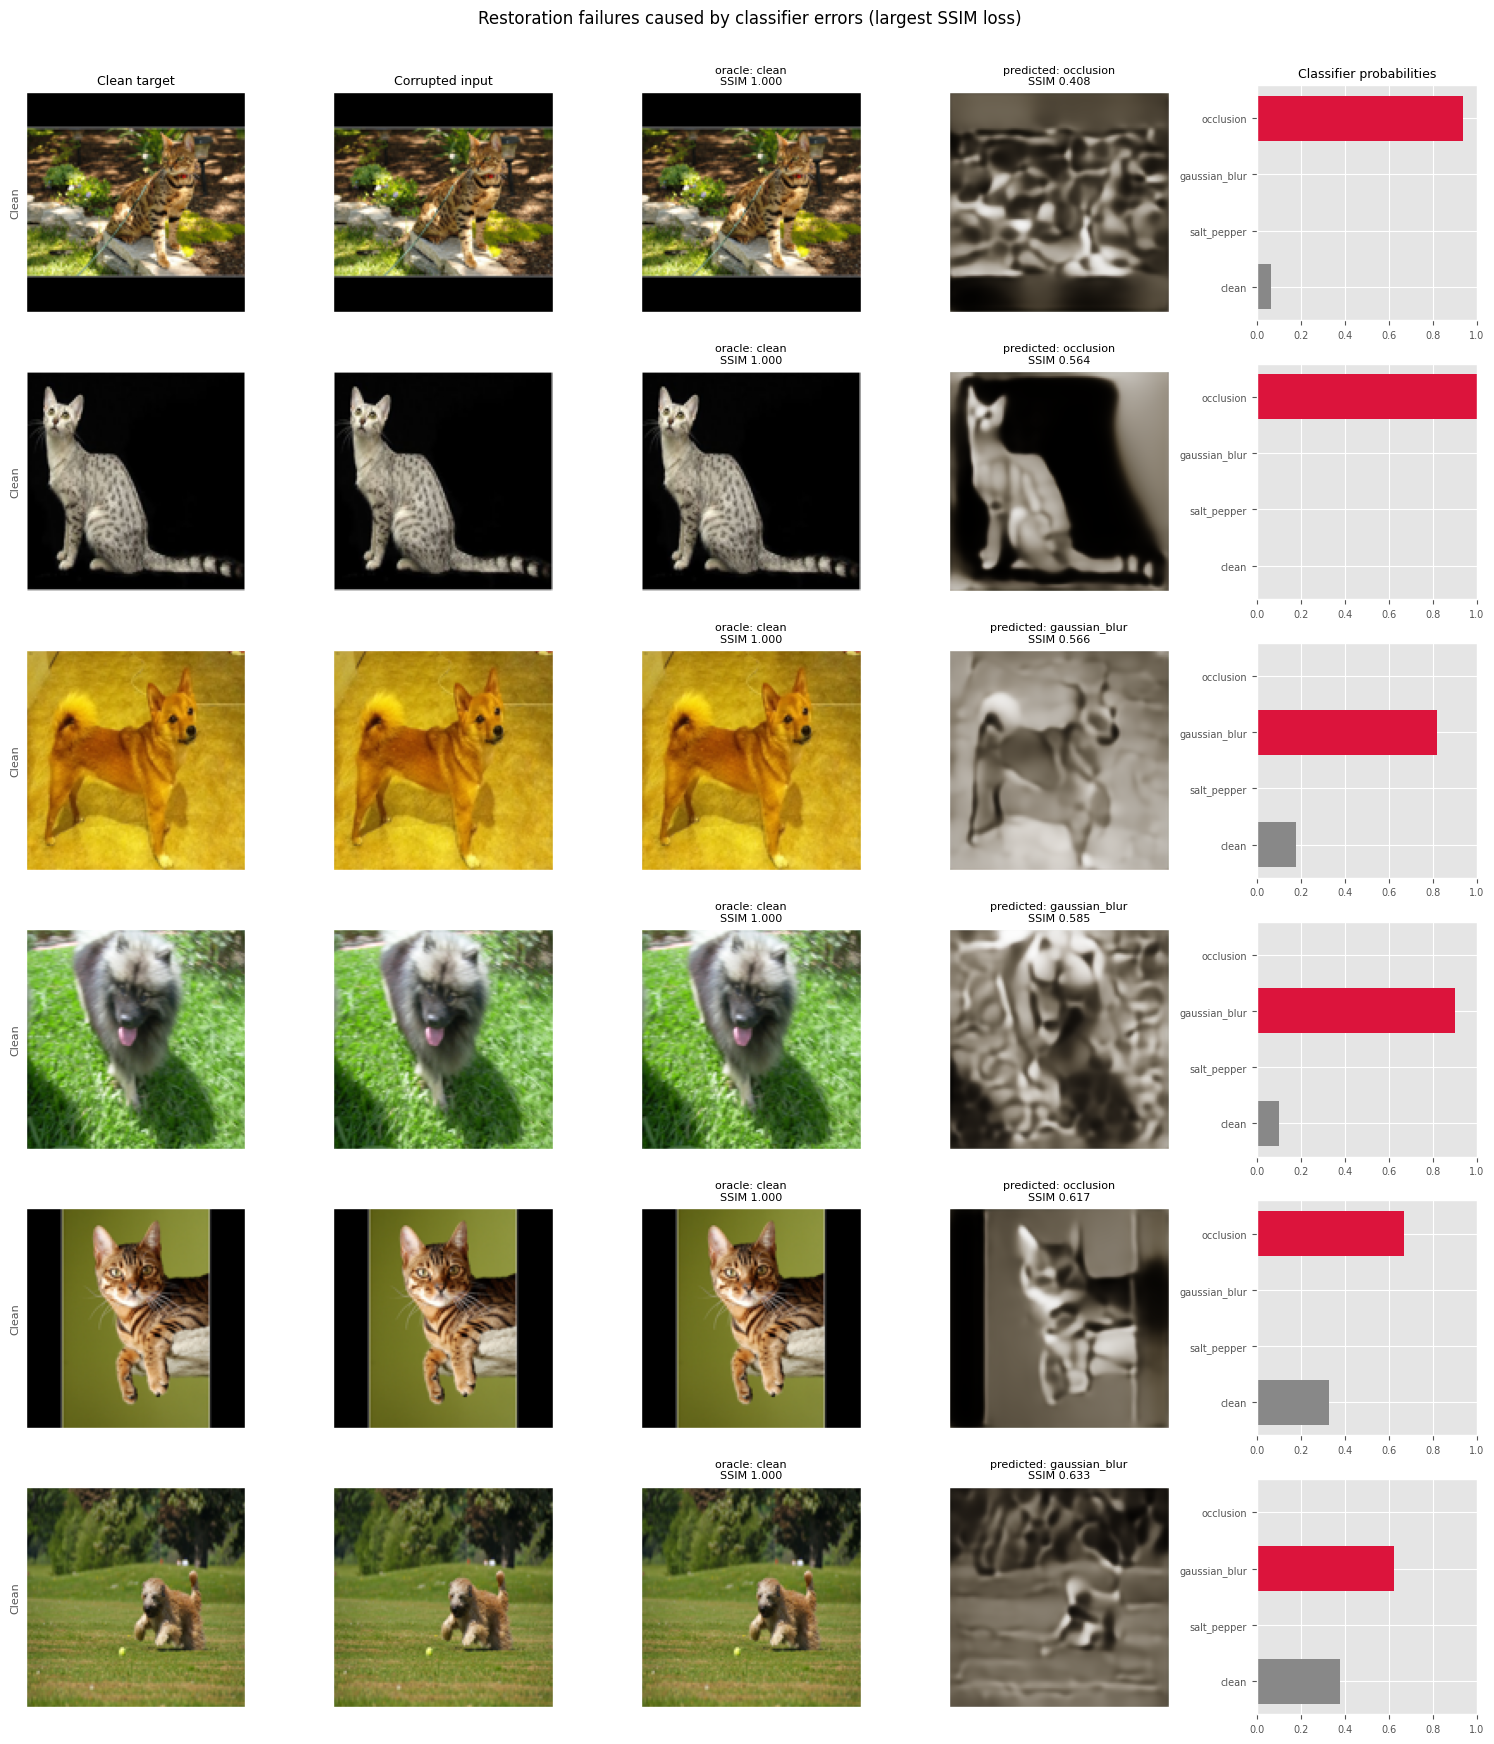

In [18]:
mis = rt[~rt.correct].copy(); mis['pred_name'] = mis.pred.map(dict(enumerate(CONDITIONS)))
print(f'{len(mis)} of {len(rt)} test entries misrouted ({100 * len(mis) / len(rt):.2f}%)')
if len(mis):
    mis_tbl = mis.groupby(['type', 'pred_name']).agg(n=('index', 'size'), mean_conf=('confidence', 'mean'),
              psnr_lost=('routing_loss_psnr', 'mean'), ssim_lost=('routing_loss_ssim', 'mean'))
    save_table(mis_tbl, 'routing_errors_by_pair'); display(mis_tbl.round(4))
    print(f"{100 * (mis.routing_loss_ssim.abs() < 0.01).mean():.1f}% of routing errors changed SSIM by less than 0.01 (harmless)")

rt_by_index = rt.set_index('index')
@torch.no_grad()
def run_entry(k):
    e = test_entries[k]
    clean = test_images[e['img_idx']].astype(np.float32) / 255.0
    corr = apply_corruption(clean, e)
    x = torch.from_numpy(np.ascontiguousarray(corr.transpose(2, 0, 1)))[None].to(device)
    pred_out, probs, pred = router(x)
    orc = router.route(x, torch.tensor([COND2IDX[e['type']]], device=device))
    f = lambda t: t[0].cpu().numpy().transpose(1, 2, 0)
    return clean, corr, f(orc), f(pred_out), probs[0].cpu().numpy()

def plot_routing_rows(ks, name, title):
    fig, axes = plt.subplots(len(ks), 5, figsize=(15, 2.9 * len(ks)), squeeze=False)
    for r, k in enumerate(ks):
        e, s = test_entries[k], rt_by_index.loc[k]
        clean, corr, orc, pred_img, probs = run_entry(k)
        for a, im in zip(axes[r, :4], [clean, corr, orc, pred_img]):
            a.imshow(im); a.set_xticks([]); a.set_yticks([])
        axes[r, 0].set_ylabel(describe(e), fontsize=8)
        axes[r, 2].set_title(f"oracle: {e['type']}\nSSIM {s.oracle_ssim:.3f}", fontsize=8)
        axes[r, 3].set_title(f"predicted: {CONDITIONS[int(s.pred)]}\nSSIM {s.pred_ssim:.3f}", fontsize=8)
        axes[r, 4].barh(CONDITIONS, probs, color=['#888' if i != int(s.pred) else 'crimson' for i in range(4)])
        axes[r, 4].set_xlim(0, 1); axes[r, 4].tick_params(labelsize=7)
    axes[0, 0].set_title('Clean target', fontsize=9); axes[0, 1].set_title('Corrupted input', fontsize=9)
    axes[0, 4].set_title('Classifier probabilities', fontsize=9)
    fig.suptitle(title, y=1.0); plt.tight_layout(); savefig(fig, name); plt.show()

if len(mis):
    worst = mis.sort_values('routing_loss_ssim', ascending=False).drop_duplicates('img_idx').head(6)['index'].tolist()
    plot_routing_rows(worst, 'routing_failures', 'Restoration failures caused by classifier errors (largest SSIM loss)')

## C3. Representative hard-routing examples with error maps

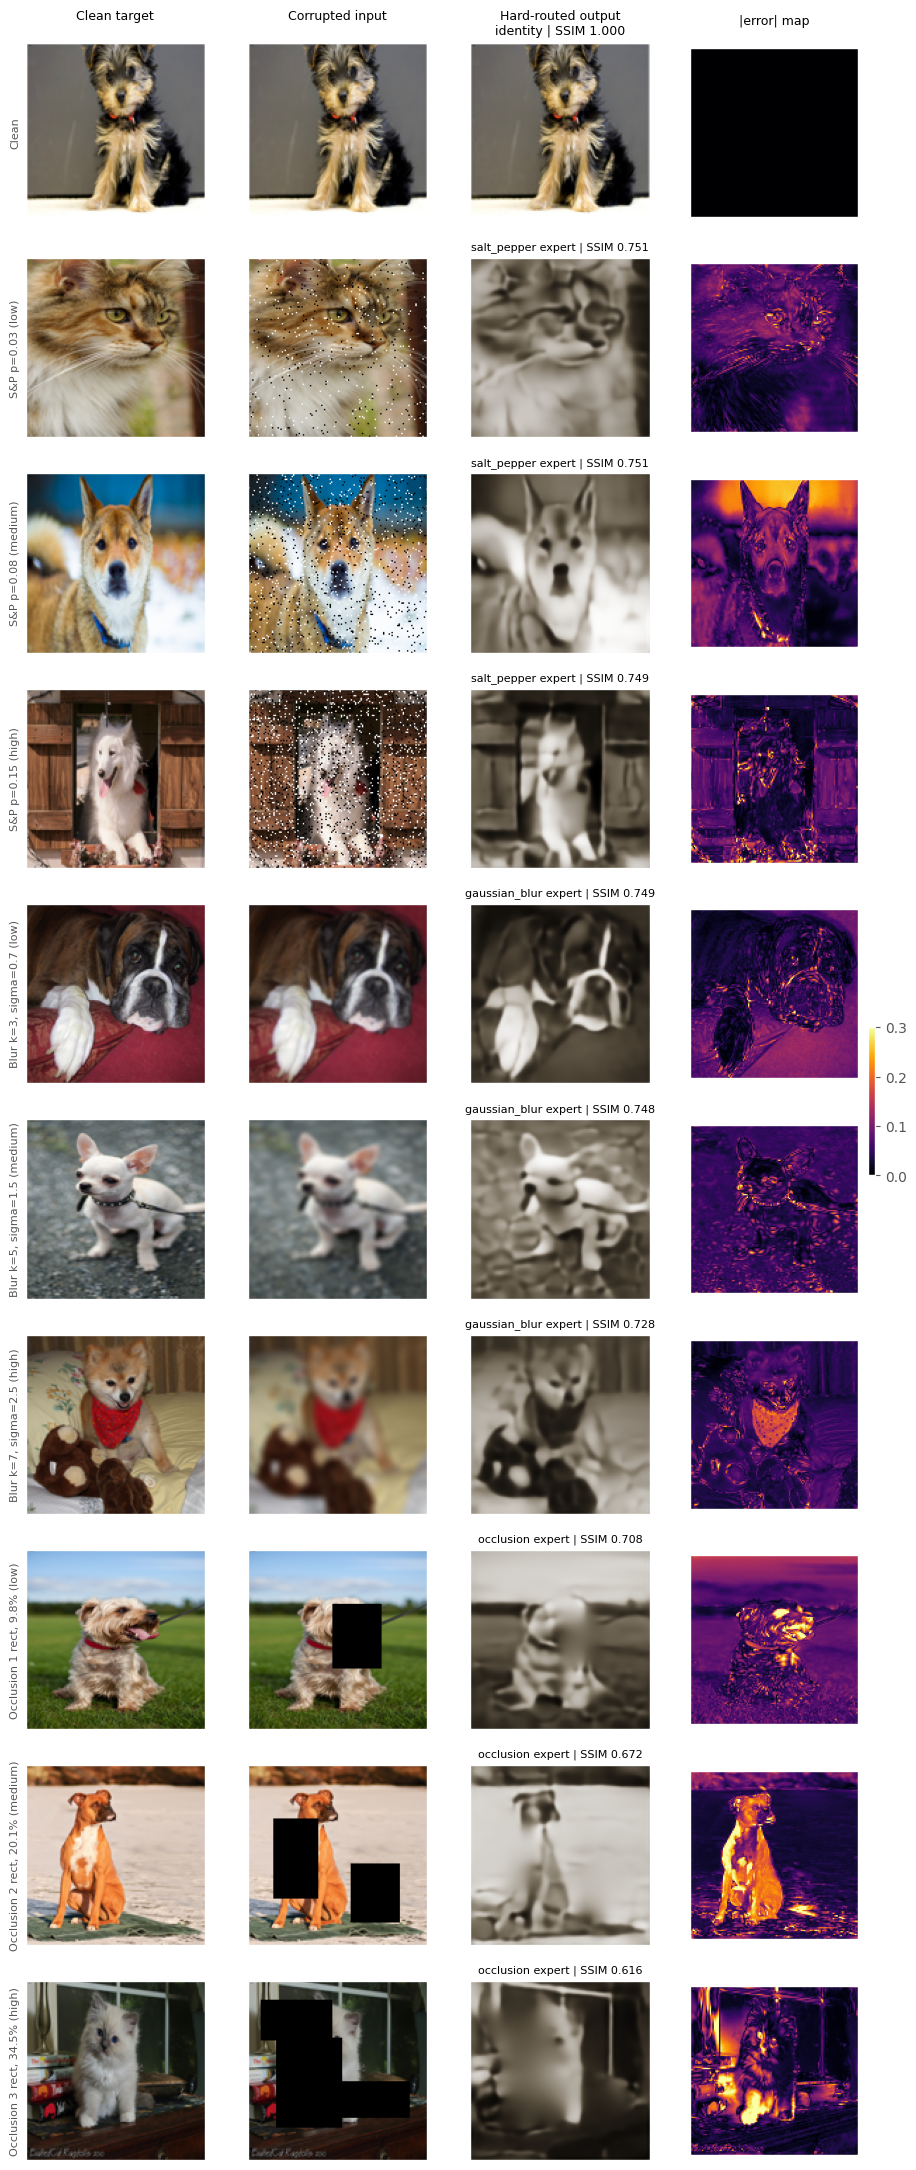

In [19]:
used, rep = set(), []
for t, s in [('clean', 'none')] + [(t, s) for t in CONDITIONS[1:] for s in SEVERITIES]:
    g = rt[(rt.type == t) & (rt.severity == s) & rt.correct]
    if not len(g): continue
    target = g.pred_ssim.median()
    for _, r in g.assign(d=(g.pred_ssim - target).abs()).sort_values('d').iterrows():
        if r.img_idx not in used:
            used.add(r.img_idx); rep.append(int(r['index'])); break
fig, axes = plt.subplots(len(rep), 4, figsize=(11, 2.75 * len(rep)), squeeze=False)
for r, k in enumerate(rep):
    e, s = test_entries[k], rt_by_index.loc[k]
    clean, corr, _, out, _ = run_entry(k)
    axes[r, 0].imshow(clean); axes[r, 1].imshow(corr); axes[r, 2].imshow(out)
    im = axes[r, 3].imshow(np.abs(out - clean).mean(2), cmap='inferno', vmin=0, vmax=0.3)
    axes[r, 0].set_ylabel(describe(e), fontsize=8)
    expert = 'identity' if int(s.pred) == 0 else f'{CONDITIONS[int(s.pred)]} expert'
    axes[r, 2].set_title(f"{expert} | SSIM {s.pred_ssim:.3f}", fontsize=8)
    for a in axes[r]: a.set_xticks([]); a.set_yticks([])
for a, t in zip(axes[0], ['Clean target', 'Corrupted input', 'Hard-routed output', '|error| map']):
    a.set_title(t + '\n' + a.get_title(), fontsize=9)
fig.colorbar(im, ax=axes[:, 3].tolist(), fraction=0.04); savefig(fig, 'routing_representative'); plt.show()

## C4. ONNX export, consistency check and timing

The classifier is exported with two outputs (`logits`, `probs`); each specialist is exported exactly as the Task 1 model (`input` to `output`). The backend performs the routing: argmax of `probs`, identity for clean, otherwise the matching specialist.

In [20]:
import onnx, onnxruntime as ort
EXPORT_KW = dict(opset_version=17)
def export(model, path, out_names):
    dyn = {'input': {0: 'batch'}, **{n: {0: 'batch'} for n in out_names}}
    dummy = torch.rand(1, 3, IMG_SIZE, IMG_SIZE)
    try:
        torch.onnx.export(model, dummy, path, input_names=['input'], output_names=out_names, dynamic_axes=dyn, dynamo=False, **EXPORT_KW)
    except TypeError:
        torch.onnx.export(model, dummy, path, input_names=['input'], output_names=out_names, dynamic_axes=dyn, **EXPORT_KW)
    onnx.checker.check_model(onnx.load(path))

def latency_ms(sess, n=50):
    x = np.random.rand(1, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
    for _ in range(5): sess.run(None, {'input': x})
    t = time.perf_counter()
    for _ in range(n): sess.run(None, {'input': x})
    return (time.perf_counter() - t) / n * 1000

check_ids = test_meta.groupby(['type', 'severity']).head(8)['index'].tolist()
xs = torch.stack([test_ds[i][0] for i in check_ids])
onnx_report = {}

clf_path = f"{PATHS['onnx']}/corruption_classifier.onnx"
wrapper = ClassifierWithProbs(copy.deepcopy(clf).cpu().eval()).eval()
export(wrapper, clf_path, ['logits', 'probs'])
sess = ort.InferenceSession(clf_path, providers=['CPUExecutionProvider'])
with torch.no_grad():
    ref = wrapper(xs)[1].numpy()
got = sess.run(['probs'], {'input': xs.numpy()})[0]
onnx_report['classifier'] = {'n_images': len(check_ids), 'max_abs_diff_probs': float(np.abs(ref - got).max()),
                             'same_argmax': bool((ref.argmax(1) == got.argmax(1)).all()), 'cpu_ms': latency_ms(sess)}
for t in EXPERT_NAMES:
    pth = f"{PATHS['onnx']}/specialist_{t}.onnx"
    cpu_m = copy.deepcopy(experts[t]).cpu().eval()
    export(cpu_m, pth, ['output'])
    sess = ort.InferenceSession(pth, providers=['CPUExecutionProvider'])
    with torch.no_grad():
        ref = cpu_m(xs).numpy()
    got = sess.run(['output'], {'input': xs.numpy()})[0]
    diff = np.abs(ref - got)
    onnx_report[f'specialist_{t}'] = {'n_images': len(check_ids), 'max_abs_diff': float(diff.max()),
                                      'mean_abs_diff': float(diff.mean()),
                                      'allclose': bool(np.allclose(ref, got, rtol=1e-3, atol=1e-4)), 'cpu_ms': latency_ms(sess)}
json.dump(onnx_report, open(f"{PATHS['results']}/onnx_verification.json", 'w'), indent=2)
print(json.dumps(onnx_report, indent=2))
assert onnx_report['classifier']['same_argmax'] and onnx_report['classifier']['max_abs_diff_probs'] < 1e-4
assert all(onnx_report[f'specialist_{t}']['allclose'] for t in EXPERT_NAMES)

backend_meta = {
    'task': 'Task 2 - Hard-Routed Restoration', 'opset': 17, 'class_order': CONDITIONS,
    'classifier': {'file': 'corruption_classifier.onnx', 'input': 'input', 'outputs': ['logits', 'probs'], 'config': CLF_CONFIG},
    'experts': {'salt_pepper': 'specialist_salt_pepper.onnx', 'gaussian_blur': 'specialist_gaussian_blur.onnx',
                'occlusion': 'specialist_occlusion.onnx', 'clean': 'identity (return input unchanged)'},
    'routing_rule': 'pred = argmax(probs); clean -> identity, otherwise run experts[class_order[pred]]',
    'input': {'shape': ['batch', 3, IMG_SIZE, IMG_SIZE], 'dtype': 'float32', 'layout': 'NCHW', 'color': 'RGB',
              'range': [0, 1], 'preprocess': 'convert to RGB, resize to 128x128 (bicubic), divide by 255'},
    'specialist_config': SPEC_FINAL, 'classifier_config': CLF_FINAL,
    'cpu_ms': {k: v['cpu_ms'] for k, v in onnx_report.items()},
}
json.dump(backend_meta, open(f"{PATHS['onnx']}/hard_routing_meta.json", 'w'), indent=2, default=str)

/tmp/ipykernel_1325/2516533682.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, path, input_names=['input'], output_names=out_names, dynamic_axes=dyn, dynamo=False, **EXPORT_KW)


{
  "classifier": {
    "n_images": 80,
    "max_abs_diff_probs": 1.5087425708770752e-07,
    "same_argmax": true,
    "cpu_ms": 5.8852549199946225
  },
  "specialist_salt_pepper": {
    "n_images": 80,
    "max_abs_diff": 1.8477439880371094e-06,
    "mean_abs_diff": 3.377656909719917e-08,
    "allclose": true,
    "cpu_ms": 133.58419896001578
  },
  "specialist_gaussian_blur": {
    "n_images": 80,
    "max_abs_diff": 2.086162567138672e-06,
    "mean_abs_diff": 3.84862168800737e-08,
    "allclose": true,
    "cpu_ms": 120.95479785999487
  },
  "specialist_occlusion": {
    "n_images": 80,
    "max_abs_diff": 8.642673492431641e-07,
    "mean_abs_diff": 4.132785491606228e-08,
    "allclose": true,
    "cpu_ms": 110.07874757997342
  }
}


## C5. W&B records and summary

In [21]:
run = wandb.init(project=WANDB_PROJECT, group='task2-final' + SUFFIX, name='task2-test-and-export' + SUFFIX, job_type='evaluation')
run.log({'test/routing_by_type': wandb.Table(dataframe=rt_type.reset_index()),
         'test/routing_by_type_severity': wandb.Table(dataframe=rt_sev.reset_index()),
         **{f'figures/{f[:-4]}': wandb.Image(f"{PATHS['figures']}/{f}")
            for f in sorted(os.listdir(PATHS['figures'])) if f.endswith('.png')}})
run.summary.update({f'clf_test/{k}': v for k, v in clf_results['test'].items()})
for t, r in rt_type.iterrows():
    k = t.replace(' ', '_')
    run.summary.update({f'routing/{k}_acc': float(r.routing_acc), f'routing/{k}_oracle_ssim': float(r.oracle_ssim),
                        f'routing/{k}_pred_ssim': float(r.pred_ssim)})
art = wandb.Artifact('task2-hard-routing' + SUFFIX, type='model', metadata={'onnx_check': onnx_report})
for f in [CLF_BEST, *[f"{PATHS['checkpoints']}/specialist_{t}_best.pt" for t in EXPERT_NAMES]]:
    art.add_file(f)
for f in os.listdir(PATHS['onnx']):
    art.add_file(f"{PATHS['onnx']}/{f}")
run.log_artifact(art); run.finish()

print('=== Classifier Optuna ===', {k: clf_optuna[k] for k in ('n_trials_total', 'n_complete', 'n_pruned', 'best_trial', 'best_value')})
print('=== Specialist Optuna ===', {k: spec_optuna[k] for k in ('n_trials_total', 'n_complete', 'n_pruned', 'best_trial', 'best_value')})
print('=== Classifier test ===', {k: round(v, 4) for k, v in clf_results['test'].items()})
print('=== Routing (test) ==='); display(rt_type[['routing_acc', 'oracle_psnr', 'pred_psnr', 'oracle_ssim', 'pred_ssim']].round(4))
for k in ('checkpoints', 'onnx', 'figures', 'results', 'optuna'):
    print(k, '->', sorted(os.listdir(PATHS[k])))

clf_test/accuracy,0.99858
clf_test/macro_f1,0.99765
clf_test/macro_precision,0.99836
clf_test/macro_recall,0.99696
routing/all_corrupted_acc,0.99967
routing/all_corrupted_oracle_ssim,0.70625
routing/all_corrupted_pred_ssim,0.70631
routing/clean_acc,0.98883
routing/clean_oracle_ssim,1
routing/clean_pred_ssim,0.99721
+9,...


=== Classifier Optuna === {'n_trials_total': 25, 'n_complete': 11, 'n_pruned': 14, 'best_trial': 22, 'best_value': 1.0}
=== Specialist Optuna === {'n_trials_total': 15, 'n_complete': 10, 'n_pruned': 5, 'best_trial': 14, 'best_value': 0.455048864086469}
=== Classifier test === {'accuracy': 0.9986, 'macro_precision': 0.9984, 'macro_recall': 0.997, 'macro_f1': 0.9977}
=== Routing (test) ===


,routing_acc,oracle_psnr,pred_psnr,oracle_ssim,pred_ssim
type,,,,,
clean,0.9888,NaN,21.8852,1.0000,0.9972
salt_pepper,1.0000,21.8480,21.8480,0.7362,0.7362
gaussian_blur,0.9995,21.8092,21.8131,0.7271,0.7272
occlusion,0.9995,19.7696,19.7731,0.6555,0.6555
all corrupted,0.9997,21.1423,21.1447,0.7062,0.7063


checkpoints -> ['classifier_best.pt', 'classifier_last.pt', 'specialist_gaussian_blur_best.pt', 'specialist_gaussian_blur_last.pt', 'specialist_occlusion_best.pt', 'specialist_occlusion_last.pt', 'specialist_salt_pepper_best.pt', 'specialist_salt_pepper_last.pt']
onnx -> ['corruption_classifier.onnx', 'hard_routing_meta.json', 'specialist_gaussian_blur.onnx', 'specialist_occlusion.onnx', 'specialist_salt_pepper.onnx']
figures -> ['clf_balanced_batch.pdf', 'clf_balanced_batch.png', 'clf_confident_errors.pdf', 'clf_confident_errors.png', 'clf_confusion_test.pdf', 'clf_confusion_test.png', 'clf_confusion_val.pdf', 'clf_confusion_val.png', 'clf_optuna_history.pdf', 'clf_optuna_history.png', 'clf_optuna_importance.pdf', 'clf_optuna_importance.png', 'clf_optuna_intermediate.pdf', 'clf_optuna_intermediate.png', 'clf_optuna_parallel.pdf', 'clf_optuna_parallel.png', 'clf_training_curves.pdf', 'clf_training_curves.png', 'routing_failures.pdf', 'routing_failures.png', 'routing_representative.pdf'

## Done: what Task 2 produced (under `genai-assignment1/`)

- `common/classifier.py`, `common/routing.py`: new shared code (repo). Task 3 imports `common/classifier.py` for its gate.
- `task2/checkpoints/classifier_best.pt` and `specialist_{salt_pepper,gaussian_blur,occlusion}_best.pt`: the inputs Task 3 needs (Git LFS or a download link). The `*_last.pt` files are resume states and do not go to GitHub.
- `task2/onnx/`: four ONNX models and `hard_routing_meta.json` for the backend.
- `task2/optuna/`: both study databases, trial CSVs and summaries (repo).
- `task2/results/`, `task2/figures/`: tables (CSV and LaTeX) and figures for the report.